<h2 style="color: #1a237e;"><b>Project Overview</b></h2>

*   I am working on Credit Score Prediction using customer financial and behavioral data.
*   Credit scores are crucial for banks and financial institutions to evaluate a customer's creditworthiness for loans or credit cards.
*   Traditional credit scoring methods can be inaccurate due to missing values, inconsistent records, and changing financial behaviors.
*   These inaccuracies can lead to poor risk assessment, financial losses for lenders, and unfair credit decisions.
*   The main objective is to build a machine learning model to accurately predict a customer's credit score.
*   This involves data cleaning, exploratory data analysis (EDA), feature engineering, and model development.
*   The model will use various financial and behavioral factors to identify patterns related to creditworthiness.
*   The final system will classify customers into three credit score categories: Good, Standard, and Poor.
*   This project will also help identify the key factors influencing credit scores.
*   The developed model aims to support financial institutions in making better lending decisions, reducing risk, and improving the overall credit assessment process.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/train.csv')

In [3]:
clean_df = df.copy()

In [4]:
clean_df.shape

(100000, 28)

In [5]:
clean_df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [6]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [7]:
clean_df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [8]:
clean_df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


## **Initial Insights**

*   After exploring the dataset, I observed that it contains both numerical and categorical features related to customers' financial behavior.
*   Some columns contain missing or inconsistent values, which need to be handled before further analysis.
*   The dataset includes multiple factors that may influence a customer's credit score, such as debt, payment history, credit utilization, and credit history.
*   A few columns require data cleaning and preprocessing to ensure accurate analysis and model performance.
*   Overall, the dataset provides sufficient information to understand customer credit behavior and build a credit score prediction model.

## Step 1: Replace Explicit and Hidden Missing Value Indicators

While exploring the dataset, I found that some missing values were represented using the symbol '_' instead of standard null values. To ensure accurate analysis and data cleaning, I first identified these hidden missing value indicators and replaced them with proper missing values (NaN).

In [9]:
# Replace explicit placeholder underscores with standard mathematical null values
clean_df['Credit_Mix'] = clean_df['Credit_Mix'].replace('_', np.nan)
clean_df['Payment_Behaviour'] = clean_df['Payment_Behaviour'].replace('!@9#%8^&', np.nan)

print("Categorical indicators checked and normalized to np.nan.")

Categorical indicators checked and normalized to np.nan.


## Step 2: Strip Contaminants from the 'Age' Column

I observed that the Age column contained unwanted characters such as underscores (_) and incorrect negative signs. These values could affect the analysis, so I cleaned the column by removing the unnecessary characters and converted it into a numeric format for further processing.

In [10]:
# Clean the Age column
clean_df['Age'] = clean_df['Age'].astype(str).str.replace('_', '', regex=False)
clean_df['Age'] = clean_df['Age'].str.strip()
clean_df['Age'] = pd.to_numeric(clean_df['Age'], errors='coerce')

print("Age column successfully processed. Datatype:", clean_df['Age'].dtype)

Age column successfully processed. Datatype: int64


## Step 3: Strip Contaminants from 'Annual_Income'

I noticed that the Annual_Income column contained unwanted underscore (_) characters along with the income values. To ensure accurate calculations and analysis, I removed these extra characters and converted the column into a numeric format.

In [11]:
# Clean the Annual Income column
clean_df['Annual_Income'] = clean_df['Annual_Income'].astype(str).str.replace('_', '', regex=False)
clean_df['Annual_Income'] = clean_df['Annual_Income'].str.strip()
clean_df['Annual_Income'] = pd.to_numeric(clean_df['Annual_Income'], errors='coerce')

print("Annual_Income successfully processed. Datatype:", clean_df['Annual_Income'].dtype)

Annual_Income successfully processed. Datatype: float64


## Step 4: Strip Contaminants from 'Num_of_Loan'

In [12]:
# Clean the Num_of_Loan column
clean_df['Num_of_Loan'] = clean_df['Num_of_Loan'].astype(str).str.replace('_', '', regex=False)
clean_df['Num_of_Loan'] = clean_df['Num_of_Loan'].str.strip()
clean_df['Num_of_Loan'] = pd.to_numeric(clean_df['Num_of_Loan'], errors='coerce')

print("Num_of_Loan successfully processed. Datatype:", clean_df['Num_of_Loan'].dtype)

Num_of_Loan successfully processed. Datatype: int64


## Step 5: Strip Contaminants from 'Num_of_Delayed_Payment'

In [13]:
# Clean the Num_of_Delayed_Payment column
clean_df['Num_of_Delayed_Payment'] = clean_df['Num_of_Delayed_Payment'].astype(str).str.replace('_', '', regex=False)
clean_df['Num_of_Delayed_Payment'] = clean_df['Num_of_Delayed_Payment'].str.strip()
clean_df['Num_of_Delayed_Payment'] = pd.to_numeric(clean_df['Num_of_Delayed_Payment'], errors='coerce')

print("Num_of_Delayed_Payment successfully processed. Datatype:", clean_df['Num_of_Delayed_Payment'].dtype)

Num_of_Delayed_Payment successfully processed. Datatype: float64


## Step 6: Strip Contaminants from 'Changed_Credit_Limit'

In [14]:
# Clean the Changed_Credit_Limit column
clean_df['Changed_Credit_Limit'] = clean_df['Changed_Credit_Limit'].astype(str).str.replace('_', '', regex=False)
clean_df['Changed_Credit_Limit'] = clean_df['Changed_Credit_Limit'].str.strip()
clean_df['Changed_Credit_Limit'] = pd.to_numeric(clean_df['Changed_Credit_Limit'], errors='coerce')

print("Changed_Credit_Limit successfully processed. Datatype:", clean_df['Changed_Credit_Limit'].dtype)

Changed_Credit_Limit successfully processed. Datatype: float64


## Step 7: Strip Contaminants from 'Outstanding_Debt'

In [15]:
# Clean the Outstanding_Debt column
clean_df['Outstanding_Debt'] = clean_df['Outstanding_Debt'].astype(str).str.replace('_', '', regex=False)
clean_df['Outstanding_Debt'] = clean_df['Outstanding_Debt'].str.strip()
clean_df['Outstanding_Debt'] = pd.to_numeric(clean_df['Outstanding_Debt'], errors='coerce')

print("Outstanding_Debt successfully processed. Datatype:", clean_df['Outstanding_Debt'].dtype)

Outstanding_Debt successfully processed. Datatype: float64


## Step 8: Strip Contaminants from 'Amount_invested_monthly'

In [16]:
# Clean the Amount_invested_monthly column
clean_df['Amount_invested_monthly'] = clean_df['Amount_invested_monthly'].astype(str).str.replace('_', '', regex=False)
clean_df['Amount_invested_monthly'] = clean_df['Amount_invested_monthly'].str.strip()
clean_df['Amount_invested_monthly'] = pd.to_numeric(clean_df['Amount_invested_monthly'], errors='coerce')

print("Amount_invested_monthly successfully processed. Datatype:", clean_df['Amount_invested_monthly'].dtype)

Amount_invested_monthly successfully processed. Datatype: float64


## Step 9: Strip Contaminants from 'Monthly_Balance'

In [17]:
# Clean the Monthly_Balance column
clean_df['Monthly_Balance'] = clean_df['Monthly_Balance'].astype(str).str.replace('_', '', regex=False)
clean_df['Monthly_Balance'] = clean_df['Monthly_Balance'].str.strip()
clean_df['Monthly_Balance'] = pd.to_numeric(clean_df['Monthly_Balance'], errors='coerce')

print("Monthly_Balance successfully processed. Datatype:", clean_df['Monthly_Balance'].dtype)

Monthly_Balance successfully processed. Datatype: float64


Insight After Data Cleaning

After cleaning multiple columns, I found that several features contained unwanted characters and formatting issues that could affect the analysis. By removing these inconsistencies and converting the columns into appropriate data types, the dataset became cleaner, more reliable, and ready for further analysis and modeling.

## Step 10: Structural Text Extraction on 'Credit_History_Age'

I noticed that the Credit_History_Age column was stored in a text format, making it difficult to use directly for analysis and modeling. Therefore, I extracted the year and month values and converted them into total months to create a numerical feature that can be used more effectively.

In [18]:
# Extract the numeric values for Years and Months using raw series string operations
extracted_years = clean_df['Credit_History_Age'].str.extract(r'(\d+)\s*Year')
extracted_months = clean_df['Credit_History_Age'].str.extract(r'(\d+)\s*Month')

# Cast the extracted values into floats, filling missing records with zero
numeric_years = pd.to_numeric(extracted_years[0], errors='coerce').fillna(0)
numeric_months = pd.to_numeric(extracted_months[0], errors='coerce').fillna(0)

# Combine the variables into a single numeric metric
clean_df['Credit_History_Age_Months'] = (numeric_years * 12) + numeric_months

# Mask records that were entirely missing or blank in the raw column back to true missing states
clean_df.loc[clean_df['Credit_History_Age'].isna() | (clean_df['Credit_History_Age'] == '_'), 'Credit_History_Age_Months'] = np.nan

# Drop the legacy string baseline column
clean_df.drop(columns=['Credit_History_Age'], inplace=True)

print("Created continuous feature 'Credit_History_Age_Months'. Datatype:", clean_df['Credit_History_Age_Months'].dtype)

Created continuous feature 'Credit_History_Age_Months'. Datatype: float64


# Structural Cleanup of Corrupted Demographics ('Age')

While analyzing the Age column, I found several unrealistic values such as negative ages, extremely high ages, and data entry errors. Since these values do not represent valid customers, I treated them as missing values. I then replaced them using the median age to maintain data consistency and avoid the impact of extreme outliers.

In [19]:
# Strip any potential whitespace strings if parsed as object, then force to numeric
clean_df['Age'] = pd.to_numeric(clean_df['Age'].astype(str).str.replace(r'[^0-9.-]', '', regex=True), errors='coerce')

# Apply operational boundary filters to mask anomalies to NaN
clean_df.loc[clean_df['Age'] < 18, 'Age'] = np.nan
clean_df.loc[clean_df['Age'] > 80, 'Age'] = np.nan

# Execute robust median imputation
age_median_val = clean_df['Age'].median()
clean_df['Age'] = clean_df['Age'].fillna(age_median_val)


print(f"Operational Target Imputation Baseline (Median): {int(age_median_val)} years old")
print("Minimum Recorded Age in Dataset                :", int(clean_df['Age'].min()))
print("Maximum Recorded Age in Dataset                :", int(clean_df['Age'].max()))


Operational Target Imputation Baseline (Median): 34 years old
Minimum Recorded Age in Dataset                : 18
Maximum Recorded Age in Dataset                : 56


 **Handling Anomalies and Data Imputation**.

During data quality analysis, I found several unrealistic and incorrect values caused by data entry errors or system-related issues. To improve data reliability, I defined valid ranges for important financial and demographic features. Values falling outside these realistic boundaries were treated as invalid and replaced using appropriate techniques such as clipping or median imputation. This ensured that the dataset remained accurate, consistent, and suitable for analysis and model training.


In [20]:
import numpy as np
import pandas as pd

# 1. Age: 18 to 80
clean_df['Age'] = pd.to_numeric(clean_df['Age'], errors='coerce')
clean_df.loc[(clean_df['Age'] < 18) | (clean_df['Age'] > 80), 'Age'] = np.nan
clean_df['Age'] = clean_df['Age'].fillna(clean_df['Age'].median())

# 2. Num_Bank_Accounts: 0 to 12
clean_df['Num_Bank_Accounts'] = pd.to_numeric(clean_df['Num_Bank_Accounts'], errors='coerce')
clean_df.loc[(clean_df['Num_Bank_Accounts'] < 0) | (clean_df['Num_Bank_Accounts'] > 12), 'Num_Bank_Accounts'] = np.nan
clean_df['Num_Bank_Accounts'] = clean_df['Num_Bank_Accounts'].fillna(clean_df['Num_Bank_Accounts'].median())

# 3. Num_Credit_Card: 0 to 12
clean_df['Num_Credit_Card'] = pd.to_numeric(clean_df['Num_Credit_Card'], errors='coerce')
clean_df.loc[(clean_df['Num_Credit_Card'] < 0) | (clean_df['Num_Credit_Card'] > 12), 'Num_Credit_Card'] = np.nan
clean_df['Num_Credit_Card'] = clean_df['Num_Credit_Card'].fillna(clean_df['Num_Credit_Card'].median())

# 4. Interest_Rate: 1% to 40%
clean_df['Interest_Rate'] = pd.to_numeric(clean_df['Interest_Rate'], errors='coerce')
clean_df.loc[(clean_df['Interest_Rate'] < 1) | (clean_df['Interest_Rate'] > 40), 'Interest_Rate'] = np.nan
clean_df['Interest_Rate'] = clean_df['Interest_Rate'].fillna(clean_df['Interest_Rate'].median())

# 5. Delay_from_due_date: Clip negatives to 0
clean_df['Delay_from_due_date'] = pd.to_numeric(clean_df['Delay_from_due_date'], errors='coerce')
clean_df.loc[clean_df['Delay_from_due_date'] < 0, 'Delay_from_due_date'] = 0

# 6. Num_of_Loan: 0 to 10
clean_df['Num_of_Loan'] = pd.to_numeric(clean_df['Num_of_Loan'], errors='coerce')
clean_df.loc[(clean_df['Num_of_Loan'] < 0) | (clean_df['Num_of_Loan'] > 10), 'Num_of_Loan'] = np.nan
clean_df['Num_of_Loan'] = clean_df['Num_of_Loan'].fillna(clean_df['Num_of_Loan'].median())

# 7. Num_of_Delayed_Payment: 0 to 30
clean_df['Num_of_Delayed_Payment'] = pd.to_numeric(clean_df['Num_of_Delayed_Payment'], errors='coerce')
clean_df.loc[(clean_df['Num_of_Delayed_Payment'] < 0) | (clean_df['Num_of_Delayed_Payment'] > 30), 'Num_of_Delayed_Payment'] = np.nan
clean_df['Num_of_Delayed_Payment'] = clean_df['Num_of_Delayed_Payment'].fillna(clean_df['Num_of_Delayed_Payment'].median())

# 8. Num_Credit_Inquiries: 0 to 20
clean_df['Num_Credit_Inquiries'] = pd.to_numeric(clean_df['Num_Credit_Inquiries'], errors='coerce')
clean_df.loc[(clean_df['Num_Credit_Inquiries'] < 0) | (clean_df['Num_Credit_Inquiries'] > 20), 'Num_Credit_Inquiries'] = np.nan
clean_df['Num_Credit_Inquiries'] = clean_df['Num_Credit_Inquiries'].fillna(clean_df['Num_Credit_Inquiries'].median())

# 9. Annual_Income: Cap at $200,000
clean_df['Annual_Income'] = pd.to_numeric(clean_df['Annual_Income'], errors='coerce')
clean_df.loc[clean_df['Annual_Income'] > 200000, 'Annual_Income'] = np.nan
clean_df['Annual_Income'] = clean_df['Annual_Income'].fillna(clean_df['Annual_Income'].median())

# 10. Total_EMI_per_month: Cap at $5,000
clean_df['Total_EMI_per_month'] = pd.to_numeric(clean_df['Total_EMI_per_month'], errors='coerce')
clean_df.loc[clean_df['Total_EMI_per_month'] > 5000, 'Total_EMI_per_month'] = np.nan
clean_df['Total_EMI_per_month'] = clean_df['Total_EMI_per_month'].fillna(clean_df['Total_EMI_per_month'].median())

# 11. Monthly_Balance: Cap between $0 and $15,000
clean_df['Monthly_Balance'] = pd.to_numeric(clean_df['Monthly_Balance'], errors='coerce')
clean_df.loc[(clean_df['Monthly_Balance'] < 0) | (clean_df['Monthly_Balance'] > 15000), 'Monthly_Balance'] = np.nan
clean_df['Monthly_Balance'] = clean_df['Monthly_Balance'].fillna(clean_df['Monthly_Balance'].median())


print(f"  Age Range              : {int(clean_df['Age'].min())} to {int(clean_df['Age'].max())} years")
print(f" -> Bank Accounts Range    : {int(clean_df['Num_Bank_Accounts'].min())} to {int(clean_df['Num_Bank_Accounts'].max())}")
print(f"  Credit Cards Range     : {int(clean_df['Num_Credit_Card'].min())} to {int(clean_df['Num_Credit_Card'].max())}")
print(f" -> Interest Rate Ceiling  : {clean_df['Interest_Rate'].max()}%")
print(f" -> Payment Delay Floor    : {clean_df['Delay_from_due_date'].min()} days")
print(f" -> Active Loan Envelope   : {int(clean_df['Num_of_Loan'].min())} to {int(clean_df['Num_of_Loan'].max())}")
print(f" -> Credit Inquiries Max   : {int(clean_df['Num_Credit_Inquiries'].max())}")
print(f" -> Monthly Balance Ceiling: ${clean_df['Monthly_Balance'].max():,.2f}")


  Age Range              : 18 to 56 years
 -> Bank Accounts Range    : 0 to 11
  Credit Cards Range     : 0 to 11
 -> Interest Rate Ceiling  : 34.0%
 -> Payment Delay Floor    : 0 days
 -> Active Loan Envelope   : 0 to 9
 -> Credit Inquiries Max   : 17
 -> Monthly Balance Ceiling: $1,602.04


## **Thinking**

### **Age (18–80)**

*   **Logic:**
    *   Individuals below 18 are generally not eligible for most credit products.
    *   Ages above 80 are uncommon in retail credit datasets and may indicate data entry errors.

*   **Action:**
    *   Values outside this range were treated as invalid.
    *   Missing values were replaced using the median age.

### **Number of Bank Accounts (0–12)**

*   **Logic:**
    *   A customer cannot have a negative number of bank accounts.
    *   Most retail customers typically maintain a limited number of accounts.

*   **Action:**
    *   Invalid values were replaced with the median value of the column.

### **Number of Credit Cards (0–12)**

*   **Logic:**
    *   Negative credit card counts are impossible.
    *   Extremely high values are likely caused by data corruption or entry mistakes.

*   **Action:**
    *   Unrealistic values were treated as missing and replaced using the median.

### **Interest Rate (1%–40%)**

*   **Logic:**
    *   Interest rates cannot be negative or zero in this context.
    *   Extremely high rates are unrealistic and may indicate data quality issues.

*   **Action:**
    *   Values outside the defined range were replaced using median imputation.

### **Delay from Due Date**

*   **Logic:**
    *   A delay cannot be negative.
    *   Negative values usually indicate that the customer paid on time or earlier than expected.

*   **Action:**
    *   Negative values were clipped to 0 instead of being removed.

### **Number of Loans (0–10)**

*   **Logic:**
    *   A customer cannot have a negative number of loans.
    *   Very high values are unlikely for a typical retail customer.

*   **Action:**
    *   Invalid values were replaced with the median number of loans.

### **Number of Delayed Payments (0–30)**

*   **Logic:**
    *   Delayed payments cannot be negative.
    *   Extremely large values may indicate data inconsistencies.

*   **Action:**
    *   Out-of-range values were treated as missing and replaced with the median.

### **Number of Credit Inquiries (0–20)**

*   **Logic:**
    *   Credit inquiries cannot be negative.
    *   Excessively high values may not represent normal customer behavior.

*   **Action:**
    *   Invalid values were replaced using the median of the feature.

### **Annual Income (≤ $200,000)**

*   **Logic:**
    *   Extremely high income values may be caused by formatting issues or outliers.
    *   Setting a realistic upper limit helps maintain data consistency.

*   **Action:**
    *   Values above the threshold were replaced using median imputation.

### **Total EMI per Month (≤ $5,000)**

*   **Logic:**
    *   Monthly EMI payments should remain within a realistic financial range.
    *   Extremely large values may represent data errors.

*   **Action:**
    *   Invalid values were replaced with the median EMI amount.

### **Monthly Balance ($0 – $15,000)**

*   **Logic:**
    *   Negative balances were considered invalid for this analysis.
    *   Extremely high balances may indicate corrupted or unrealistic records.

*   **Action:**
    *   Out-of-range values were replaced using the median balance.

### **Why Median Imputation?**

*   **Logic:**
    *   Financial datasets often contain extreme values and outliers.
    *   The median is less affected by these extreme values compared to the mean.

*   **Reason for Use:**
    *   Median imputation helps preserve the overall distribution of the data while reducing the impact of outliers, making the dataset more reliable for analysis and model training.

<h2 style="color: yellow">Deep Architectural Evaluation & Imputation Strategy Decisions</h2>

### Missing Value Imputation Strategy
After cleaning the dataset, I analyzed each feature to determine the most appropriate method for handling missing values. Different imputation techniques were selected based on the data type, feature characteristics, and business relevance. Numerical features were mostly imputed using the median to reduce the impact of outliers, while categorical features were handled using mode, forward/backward filling, or custom replacement values. This approach helped preserve the original data patterns and improved the overall quality of the dataset.

### Key Decisions and Logic

#### Name
*   Since names are text values, statistical methods such as mean or median cannot be applied.
*   Missing names were filled using forward-fill and backward-fill within the same customer timeline.
*   Remaining missing values were labeled as "Unknown Customer".

#### Monthly_Inhand_Salary
*   Salary is strongly related to a customer's occupation.
*   Missing salaries were filled using the median salary of customers with the same occupation.

#### Credit_Mix
*   This is a categorical feature with limited categories.
*   Missing values were filled using the most frequent category (mode).

#### Type_of_Loan
*   Missing loan descriptions may indicate that the customer has no active loans.
*   Missing values were replaced with "No Active Loan Portfolio".

#### Numerical Features
*   Features such as Age, Outstanding Debt, Number of Loans, and Monthly Balance were imputed using the median.
*   Median was chosen because it is less affected by extreme values and outliers.

#### Payment_of_Min_Amount
*   If Total EMI was 0, the value was filled with "No".
*   Otherwise, missing values were replaced with the most common category.

#### Payment_Behaviour
*   Missing values were filled using the mode to preserve the overall behavioral distribution.

#### Credit_Score (Target Variable)
*   Missing target labels were not imputed.
*   Rows with missing credit scores were removed because machine learning models require genuine target labels for training.

## Resources

Data Standardization & Value Normalization

While exploring the categorical features, I found that some values contained extra characters, symbols, and formatting inconsistencies. Although these values looked similar, the system treated them as different categories. To ensure consistency, I cleaned and standardized the text values in the Occupation and Payment_Behaviour columns.

Why was this done?

Occupation

Values such as "Scientist" and "Scientist_" represent the same profession.
Extra symbols and unwanted characters were removed to create uniform categories.
This prevents the creation of duplicate categories during analysis.

Payment_Behaviour

Some records contained formatting issues and unwanted characters.
These values were standardized so that the same payment behavior is represented consistently throughout the dataset.
Advanced Categorical Standardization

After standardizing the text values, I found a few remaining anomalies such as empty occupation values and corrupted payment behavior records. These invalid entries were converted into missing values and then imputed using appropriate replacement strategies.

Why was this done?

Occupation

Empty strings indicated missing occupation information.
These values were converted to missing values (NaN).
Missing occupations were filled using the most frequent occupation category (mode).

Payment_Behaviour

Corrupted values such as random character strings did not represent any valid payment behavior.
These records were converted to missing values (NaN).
Missing values were filled using the most common payment behavior category.
Insight

After standardization, categorical features became cleaner and more consistent. This reduced duplicate categories, improved data quality, and ensured that the model would learn from meaningful customer behavior rather than formatting errors or corrupted records.

In [21]:
# Ensure chronological alignment by sorting the dataframe by Customer ID and Month sequence
clean_df = clean_df.sort_values(by=['Customer_ID', 'Month']).reset_index(drop=True)


In [22]:
# ----------------------------------------------------
# IMPUTATION TASK 1: Grouped Temporal Filling for 'Name'
# ----------------------------------------------------
clean_df['Name'] = clean_df.groupby('Customer_ID')['Name'].ffill()
clean_df['Name'] = clean_df.groupby('Customer_ID')['Name'].bfill()
clean_df['Name'] = clean_df['Name'].fillna("Unknown Customer")

In [23]:
# IMPUTATION TASK 2: Grouped Median Filling for 'Monthly_Inhand_Salary'
# ----------------------------------------------------
# Calculate the median salary for each occupation group
occupation_medians = clean_df.groupby('Occupation')['Monthly_Inhand_Salary'].transform('median')
clean_df['Monthly_Inhand_Salary'] = clean_df['Monthly_Inhand_Salary'].fillna(occupation_medians)

In [24]:
# IMPUTATION TASK 3: Mode Filling for 'Credit_Mix'
# ----------------------------------------------------
credit_mix_mode = clean_df['Credit_Mix'].mode()[0]
clean_df['Credit_Mix'] = clean_df['Credit_Mix'].fillna(credit_mix_mode)

In [25]:
#IMPUTATION TASK 4: Custom Value Filling for 'Type_of_Loan'
# ----------------------------------------------------
clean_df['Type_of_Loan'] = clean_df['Type_of_Loan'].fillna("No Active Loan Portfolio")

In [26]:
# IMPUTATION TASK 5: Median Filling for Remaining Numerical Features
# ----------------------------------------------------
clean_df['Age'] = clean_df['Age'].fillna(clean_df['Age'].median())
clean_df['Num_of_Loan'] = clean_df['Num_of_Loan'].fillna(clean_df['Num_of_Loan'].median())
clean_df['Num_of_Delayed_Payment'] = clean_df['Num_of_Delayed_Payment'].fillna(clean_df['Num_of_Delayed_Payment'].median())
clean_df['Changed_Credit_Limit'] = clean_df['Changed_Credit_Limit'].fillna(clean_df['Changed_Credit_Limit'].median())
clean_df['Num_Credit_Inquiries'] = clean_df['Num_Credit_Inquiries'].fillna(clean_df['Num_Credit_Inquiries'].median())
clean_df['Amount_invested_monthly'] = clean_df['Amount_invested_monthly'].fillna(clean_df['Amount_invested_monthly'].median())
clean_df['Monthly_Balance'] = clean_df['Monthly_Balance'].fillna(clean_df['Monthly_Balance'].median())
clean_df['Credit_History_Age_Months'] = clean_df['Credit_History_Age_Months'].fillna(clean_df['Credit_History_Age_Months'].median())
clean_df['Num_Bank_Accounts'] = clean_df['Num_Bank_Accounts'].fillna(clean_df['Num_Bank_Accounts'].median())
clean_df['Num_Credit_Card'] = clean_df['Num_Credit_Card'].fillna(clean_df['Num_Credit_Card'].median())
clean_df['Outstanding_Debt'] = clean_df['Outstanding_Debt'].fillna(clean_df['Outstanding_Debt'].median())
clean_df['Credit_Utilization_Ratio'] = clean_df['Credit_Utilization_Ratio'].fillna(clean_df['Credit_Utilization_Ratio'].median())
clean_df['Total_EMI_per_month'] = clean_df['Total_EMI_per_month'].fillna(clean_df['Total_EMI_per_month'].median())

print("Imputation tasks complete.")

Imputation tasks complete.


In [27]:
# 6. IMPUTATION TASK: Payment_of_Min_Amount (Conditional Risk Engine)
min_payment_mode_val = clean_df['Payment_of_Min_Amount'].mode()[0]
# Apply the mode as a general base fill
clean_df['Payment_of_Min_Amount'] = clean_df['Payment_of_Min_Amount'].fillna(min_payment_mode_val)
# Adjust to "No" for clear zero-liability accounts where Total EMI is zero
clean_df.loc[clean_df['Total_EMI_per_month'] == 0, 'Payment_of_Min_Amount'] = "No"


In [28]:
# 7. IMPUTATION TASK: Payment_Behaviour (Mode Imputation)
payment_behavior_mode_val = clean_df['Payment_Behaviour'].mode()[0]
clean_df['Payment_Behaviour'] = clean_df['Payment_Behaviour'].fillna(payment_behavior_mode_val)

In [29]:
# 8. TARGET PURGING: Explicitly Drop Rows where Target Variable is Null
clean_df = clean_df.dropna(subset=['Credit_Score']).reset_index(drop=True)

In [30]:
clean_df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


Duplicate Data Profiling

I checked the dataset for duplicate records to ensure that the same customer information was not repeated multiple times. Duplicate entries can create bias in the analysis and may affect the performance of the machine learning model. Therefore, duplicate records were identified and removed to maintain data accuracy and consistency.

Why was this done?
Exact duplicate rows do not provide any new information and can lead to overrepresentation of certain records.
A customer should have only one valid record for a particular month.
Multiple entries for the same customer and month may indicate data collection or system errors.
Removing duplicates helps maintain a clean and reliable customer timeline.
Insight

After removing duplicate records, the dataset became more accurate and representative of actual customer information. This helped reduce data redundancy and ensured that each customer record contributed fairly to the analysis and model training.

In [31]:
absolute_duplicates_count = clean_df.duplicated().sum()
absolute_duplicates_count


np.int64(0)

In [32]:
timeline_key_clashes = clean_df.duplicated(subset=['Customer_ID', 'Month']).sum()
timeline_key_clashes

np.int64(0)

In [34]:
clean_df['Occupation'] = clean_df['Occupation'].astype(str).str.replace('_', '', regex=False).str.strip()
clean_df['Occupation'] = clean_df['Occupation'].replace('', np.nan)
occupation_mode_val = clean_df['Occupation'].mode()[0]
clean_df['Occupation'] = clean_df['Occupation'].fillna(occupation_mode_val)

clean_df['Payment_Behaviour'] = clean_df['Payment_Behaviour'].astype(str).str.replace('_', ' ', regex=False).str.strip()
clean_df['Payment_Behaviour'] = clean_df['Payment_Behaviour'].replace('!@9#%8', np.nan)
payment_behavior_mode_val = clean_df['Payment_Behaviour'].mode()[0]
clean_df['Payment_Behaviour'] = clean_df['Payment_Behaviour'].fillna(payment_behavior_mode_val)

print("Unique Clean Occupations:\n", clean_df['Occupation'].unique())
print("\nUnique Clean Payment Behaviours:\n", clean_df['Payment_Behaviour'].unique())

Unique Clean Occupations:
 ['Lawyer' 'Mechanic' 'MediaManager' 'Doctor' 'Journalist' 'Accountant'
 'Manager' 'Entrepreneur' 'Scientist' 'Architect' 'Teacher' 'Engineer'
 'Writer' 'Developer' 'Musician']

Unique Clean Payment Behaviours:
 ['Low spent Small value payments' 'High spent Medium value payments'
 'High spent Small value payments' 'Low spent Large value payments'
 'Low spent Medium value payments' 'High spent Large value payments']


Statistical Outlier Profiling using IQR

After cleaning the data, I performed outlier analysis to identify unusually high or low values in important financial features. For this purpose, I used the Interquartile Range (IQR) method, which helps detect observations that lie far away from the majority of the data.

Why was this done?
Financial features such as income, debt, and EMI often contain extreme values.
These extreme values can influence statistical analysis and machine learning models.
IQR helps identify such unusual observations in a systematic way.
Instead of removing these records, I only analyzed their presence to better understand the data distribution.
Insight

The outlier analysis helped me identify features that contain extreme financial values. Since these records may still represent genuine customers, they were not removed. Understanding their distribution will help in selecting appropriate scaling and feature engineering techniques during model development.

In [35]:
q1_debt = clean_df['Outstanding_Debt'].quantile(0.25)
q3_debt = clean_df['Outstanding_Debt'].quantile(0.75)
iqr_debt = q3_debt - q1_debt
upper_debt_fence = q3_debt + 1.5 * iqr_debt
count_debt_outliers = clean_df[clean_df['Outstanding_Debt'] > upper_debt_fence].shape[0]

q1_income = clean_df['Annual_Income'].quantile(0.25)
q3_income = clean_df['Annual_Income'].quantile(0.75)
iqr_income = q3_income - q1_income
upper_income_fence = q3_income + 1.5 * iqr_income
count_income_outliers = clean_df[clean_df['Annual_Income'] > upper_income_fence].shape[0]

q1_emi = clean_df['Total_EMI_per_month'].quantile(0.25)
q3_emi = clean_df['Total_EMI_per_month'].quantile(0.75)
iqr_emi = q3_emi - q1_emi
upper_emi_fence = q3_emi + 1.5 * iqr_emi
count_emi_outliers = clean_df[clean_df['Total_EMI_per_month'] > upper_emi_fence].shape[0]


print("         IQR STATISTICAL TAIL OUTLIERS OUTCOME      ")

print(f"Outstanding Debt Tail Outliers      : {count_debt_outliers} records")
print(f"Annual Income Tail Outliers         : {count_income_outliers} records")
print(f"Total Monthly EMI Tail Outliers     : {count_emi_outliers} records")


         IQR STATISTICAL TAIL OUTLIERS OUTCOME      
Outstanding Debt Tail Outliers      : 5272 records
Annual Income Tail Outliers         : 2007 records
Total Monthly EMI Tail Outliers     : 5534 records


In [36]:
clean_df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Age_Months
0,0x1628d,CUS_0x1000,April,Alistair Barrf,34.0,913-74-1218,Lawyer,30625.94,2706.161667,6.0,...,Bad,1562.91,32.843081,Yes,42.941090,87.909909,Low spent Small value payments,419.765167,Poor,125.0
1,0x16291,CUS_0x1000,August,Alistair Barrf,18.0,913-74-1218,Lawyer,30625.94,2706.161667,6.0,...,Bad,1562.91,30.077191,Yes,42.941090,77.314276,High spent Medium value payments,400.360801,Poor,129.0
2,0x1628b,CUS_0x1000,February,Alistair Barrf,34.0,913-74-1218,Lawyer,30625.94,2902.293333,6.0,...,Bad,1562.91,29.439759,Yes,42.941090,176.132567,High spent Small value payments,311.542510,Poor,123.0
3,0x1628a,CUS_0x1000,January,Alistair Barrf,34.0,913-74-1218,Lawyer,30625.94,2706.161667,6.0,...,Bad,1562.91,26.612093,Yes,42.941090,244.750283,Low spent Large value payments,252.924793,Standard,122.0
4,0x16290,CUS_0x1000,July,Alistair Barrf,18.0,913-74-1218,Lawyer,30625.94,2706.161667,6.0,...,Bad,1562.91,38.149539,Yes,42.941090,266.597160,Low spent Small value payments,251.077916,Poor,128.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25afa,CUS_0xffd,January,Damouniq,29.0,832-88-8320,Scientist,41398.44,3749.870000,8.0,...,Standard,1701.88,29.506673,Yes,182.976649,195.529273,Low spent Large value payments,266.481077,Standard,218.0
99996,0x25b00,CUS_0xffd,July,Damouniq,30.0,832-88-8320,Scientist,41398.44,3749.870000,8.0,...,Standard,1701.88,33.916363,Yes,182.976649,257.989694,High spent Small value payments,194.020657,Good,224.0
99997,0x25aff,CUS_0xffd,June,Damouniq,29.0,832-88-8320,Scientist,41398.44,3260.465000,8.0,...,Standard,1701.88,36.970072,Yes,182.976649,47.007379,High spent Medium value payments,395.002972,Standard,223.0
99998,0x25afc,CUS_0xffd,March,Damouniq,29.0,832-88-8320,Scientist,41398.44,3749.870000,8.0,...,Standard,1701.88,25.175964,Yes,182.976649,336.130231,Low spent Small value payments,145.880119,Standard,220.0


Export the in-memory dataframe to a frozen, clean CSV file

In [37]:
output_filename = "sanitized_credit_portfolio.csv"
clean_df.to_csv(output_filename, index=False)

In [38]:
import pandas as pd
import numpy as np
import re

# Load the dataset
df = pd.read_csv('sanitized_credit_portfolio.csv')
print(f"Initial shape: {df.shape}")


# CRITICAL BLOCKER 1: Clean the "and " prefix artifact from Type_of_Loan

def clean_loan_string(text):
    if pd.isna(text):
        return text
    # Remove the structural "and " that sits before the last item
    text = re.sub(r'\band\s+', '', text)
    # Clean up any accidental double spaces or trailing spaces
    items = [item.strip() for item in text.split(',')]
    # Filter out empty strings if any
    items = [item for item in items if item]
    return ", ".join(items)

df['Type_of_Loan'] = df['Type_of_Loan'].apply(clean_loan_string)



# Fix Monthly_Inhand_Salary vs Annual_Income

# If monthly * 12 is greater than annual, annual income was likely
# stored as a monthly figure. Let's recalculate Annual_Income for those rows.
salary_overshoot_mask = (df['Monthly_Inhand_Salary'] * 12) > df['Annual_Income']

# Recalculate Annual_Income based on the verified monthly salary for consistency
df.loc[salary_overshoot_mask, 'Annual_Income'] = df.loc[salary_overshoot_mask, 'Monthly_Inhand_Salary'] * 12



# Revert 'Lawyer' Masked Nulls via Customer Profile

# Group by Customer_ID to find the true dominant occupation for each customer
# ignoring 'Lawyer' if they have other valid occupations.
def find_true_occupation(group):
    unique_occupations = group['Occupation'].unique()
    valid_occupations = [occ for occ in unique_occupations if occ != 'Lawyer']

    if len(valid_occupations) > 0:
        # Assign the most frequent valid occupation
        return group['Occupation'].replace('Lawyer', valid_occupations[0])
    else:
        # If they are genuinely only marked as 'Lawyer', leave them or map to 'Unknown'
        return group['Occupation']

df['Occupation'] = df.groupby('Customer_ID', group_keys=False).apply(find_true_occupation)



#  Handle Corrupted SSN String

# Replace the garbage string placeholder with NaN so it doesn't trick grouping/join logic
df['SSN'] = df['SSN'].replace('#F%$D@*&8', np.nan)



# HIGH/MEDIUM FINDINGS REMEDIATION


# 1. Total_EMI_per_month > Outstanding_Debt Cap
# Cap the EMI at the outstanding debt value for financial sanity
df['Total_EMI_per_month'] = np.minimum(df['Total_EMI_per_month'], df['Outstanding_Debt'])

# 2. Payment_of_Min_Amount 'NM' Encoding
# 'NM' typically stands for "Not Mentioned". Let's explicitly change it to 'Unknown'
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', 'Unknown')

# 3. Recalculate Num_of_Loan based on the newly cleaned Type_of_Loan string
def count_loans(text):
    if pd.isna(text) or text.strip() == "" or text.lower() == "no loan":
        return 0
    return len(text.split(','))

df['Num_of_Loan'] = df['Type_of_Loan'].apply(count_loans)


# Save the fully production-ready dataset
df.to_csv('production_ready_credit_portfolio.csv', index=False)
print("Pipeline complete! 'production_ready_credit_portfolio.csv' generated safely.")

Initial shape: (100000, 28)
Pipeline complete! 'production_ready_credit_portfolio.csv' generated safely.


## Customer-Level Age Consistency Check

While analyzing the customer records over time, I found that the Age value was not consistent for many customers. Since age can normally increase by only one year over a short period, large changes in age within the same customer timeline indicate data quality issues.

### Why was this done?

*   A customer's age should remain stable or increase by only one year over a few months.
*   Some customers showed unrealistic age changes, such as moving from 34 years to 55 years within the same observation period.
*   These large jumps are likely caused by data entry errors or corrupted records.
*   Since age is an important factor in credit score prediction, maintaining consistency is essential.

### Action Taken

*   For customers with inconsistent age values, I replaced the incorrect values using the most frequently occurring age (mode) for that customer.
*   This ensured that each customer had a consistent and realistic age throughout their timeline.

In [39]:
# Replace impossible age values with the customer's modal age
df['Age'] = df.groupby('Customer_ID')['Age']\
    .transform(lambda x: x.fillna(x.mode()[0]) if x.nunique() > 1 else x)
# More robust: replace minority age with majority age per customer
def fix_age(group):
    modal_age = group['Age'].mode()[0]
    group['Age'] = modal_age
    return group
df = df.groupby('Customer_ID', group_keys=False).apply(fix_age)

## Consistency Check and Feature Refinement

During the data quality assessment, I found that some features contained values that were likely introduced during the imputation process or due to missing data. Since these features are important for credit score prediction, I performed additional consistency checks and used customer-level information to improve their accuracy.

### Num_of_Delayed_Payment

### Why was this checked?

*   A large number of records had the exact value 14, which is the median of the column.
*   This indicated that many missing values were likely filled using a global median.
*   Since payment delays are an important indicator of credit behavior, excessive use of a single value can reduce the feature's predictive power.

### Action Taken

*   Instead of relying only on the global median, I examined customer-level payment history.
*   For customers with valid values in other months, missing values were filled using their own historical payment behavior.
*   This helped preserve individual customer patterns.

### Insight

*   Using customer-specific information provided a more realistic representation of payment behavior and reduced the risk of introducing artificial patterns into the dataset.

## Num_Bank_Accounts Consistency Check

### Why was this checked?

*   Some customers had a mix of valid values and zero values across different months.
*   Since the number of bank accounts generally remains stable over a short period, these inconsistencies suggested missing or incorrect records.

### Action Taken

*   For customers with valid account counts in other months, missing values were filled using forward-fill and backward-fill within the customer's timeline.
*   For customers whose values were missing across all months, a fallback value of 5 was used based on the typical account count observed in similar customers.

### Insight

*   Customer-level imputation helped maintain consistency across monthly records and produced more realistic account information for model training.

In [40]:
import pandas as pd
import numpy as np

df = pd.read_csv('production_ready_credit_portfolio.csv')

# Step 1: Sort by customer and month (critical for ffill/bfill to be chronologically meaningful)
month_order = ['January','February','March','April','May','June','July','August']
df['Month_num'] = df['Month'].map({m: i for i, m in enumerate(month_order)})
df = df.sort_values(['Customer_ID', 'Month_num']).reset_index(drop=True)

# Step 2: Mark the false zeros as NaN (only where we know it's invalid —
# i.e., the customer has credit cards or loans, proving they must have a bank account)
invalid_zero_mask = (df['Num_Bank_Accounts'] == 0) & \
                    ((df['Num_Credit_Card'] > 0) | (df['Num_of_Loan'] > 0))

df.loc[invalid_zero_mask, 'Num_Bank_Accounts'] = np.nan

# Step 3: ffill then bfill within each customer
# This perfectly handles the 88 "mixed" customers using their own valid months
df['Num_Bank_Accounts'] = df.groupby('Customer_ID')['Num_Bank_Accounts'] \
    .transform(lambda x: x.ffill().bfill())

# Step 4: Fallback to mode (5) for the 475 all-zero customers
# Justified: their credit-card profile (mean 4.26 cards) matches the population
# where the mode of Num_Bank_Accounts is 5
df['Num_Bank_Accounts'] = df['Num_Bank_Accounts'].fillna(5)

# Step 5: Drop the helper column
df = df.drop(columns='Month_num')

# Verify
print(df['Num_Bank_Accounts'].value_counts().sort_index())
print("Zeros remaining:", (df['Num_Bank_Accounts'] == 0).sum())  # should be 0
print("NaNs remaining:", df['Num_Bank_Accounts'].isna().sum())   # should be 0

Num_Bank_Accounts
1.0      4546
2.0      4304
3.0     11950
4.0     12186
5.0     17726
6.0     13001
7.0     12823
8.0     12765
9.0      5443
10.0     5247
11.0        9
Name: count, dtype: int64
Zeros remaining: 0
NaNs remaining: 0


In [41]:
df.to_csv('production_ready_credit_portfolio.csv', index=False)

#EDA




Univariate Analysis: Credit Score Distribution

Before building the machine learning model, I first analyzed the distribution of the target variable Credit_Score. This helped me understand how customers are distributed across the Good, Standard, and Poor credit score categories.

Why was this done?

The target variable is the feature that the model will learn to predict.
Checking its distribution helps identify whether the classes are balanced or imbalanced.
A highly imbalanced dataset can bias the model toward the majority class.
Understanding class distribution helps in selecting appropriate evaluation metrics during model training.

Insight

By analyzing the Credit_Score distribution, I gained a clear understanding of the target classes present in the dataset. This helps ensure that the model evaluation process considers class balance and provides a more reliable assessment of predictive performance.

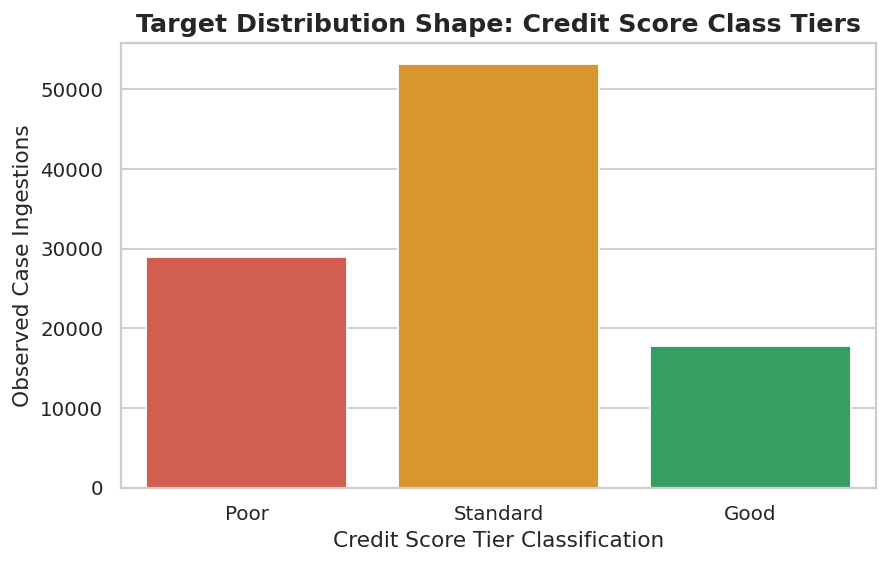

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

target_order = ['Poor', 'Standard', 'Good']

credit_colors = {
    'Poor': '#E74C3C',      # Red
    'Standard': '#F39C12',  # Orange
    'Good': '#27AE60'       # Green
}

plt.figure(figsize=(7, 4.5))

sns.countplot(
    data=clean_df,
    x='Credit_Score',
    order=target_order,
    palette=credit_colors
)

plt.title('Target Distribution Shape: Credit Score Class Tiers', fontsize=14, fontweight='bold')
plt.xlabel('Credit Score Tier Classification')
plt.ylabel('Observed Case Ingestions')

plt.tight_layout()
plt.show()

Key Insights

Most customers belong to the Standard credit score category, making it the dominant class in the dataset.

The dataset is imbalanced, as the Good category has significantly fewer records compared to Standard and Poor credit score categories.

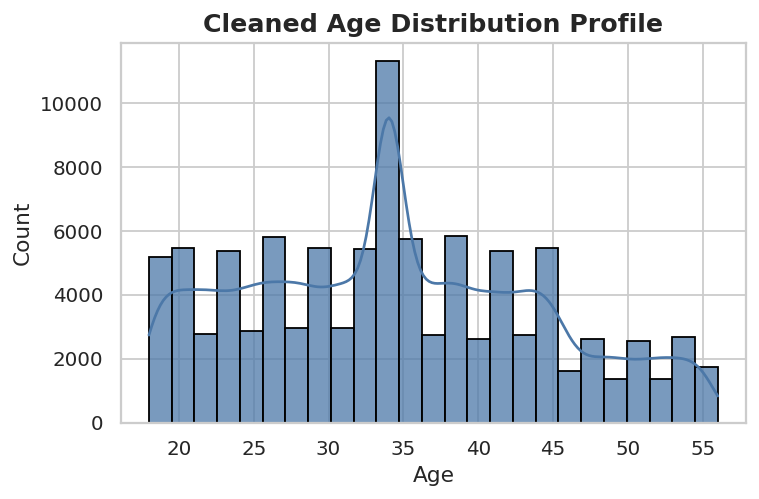

In [74]:
plt.figure(figsize=(6, 4))

sns.histplot(
    data=clean_df,
    x='Age',
    kde=True,
    bins=25,
    color='#4C78A8',  # Professional Blue
    edgecolor='black',
    alpha=0.75
)

plt.title('Cleaned Age Distribution Profile', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Key Insights

Most customers are concentrated between 30 and 40 years of age, with the highest frequency around 35 years.

The age distribution appears fairly balanced after cleaning, with no extreme or unrealistic age values remaining in the dataset.

## 1. Univariate Analysis: Distribution Spreads of Key Financial Risk Metrics

Let's plot the density distributions of 'Annual_Income' and 'Outstanding_Debt'.

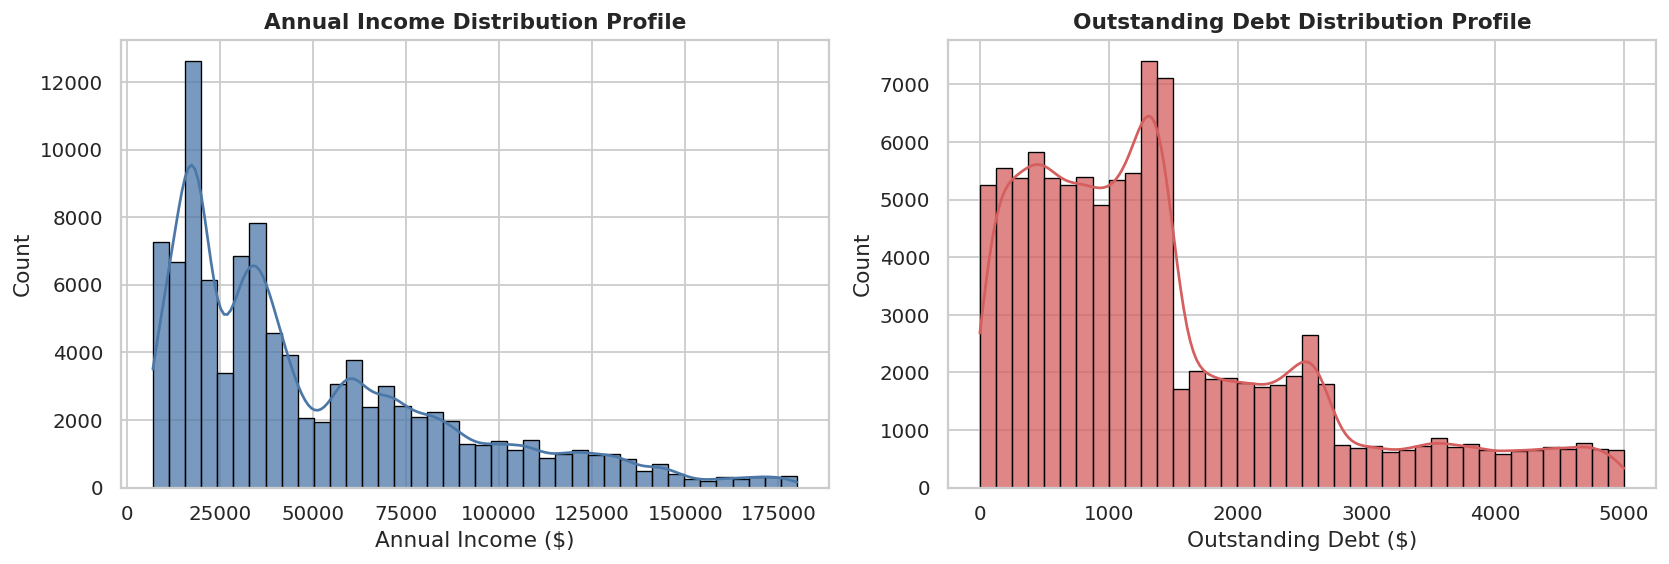

In [75]:
plt.figure(figsize=(13, 4.5))

plt.subplot(1, 2, 1)
sns.histplot(
    data=clean_df,
    x='Annual_Income',
    kde=True,
    bins=40,
    color='#4C78A8',  # Professional Blue
    edgecolor='black',
    alpha=0.75
)
plt.title('Annual Income Distribution Profile')
plt.xlabel('Annual Income ($)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(
    data=clean_df,
    x='Outstanding_Debt',
    kde=True,
    bins=40,
    color='#D55E5E',  # Soft Risk Red
    edgecolor='black',
    alpha=0.75
)
plt.title('Outstanding Debt Distribution Profile')
plt.xlabel('Outstanding Debt ($)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Key Insights

Most customers have an annual income between $10,000 and $50,000, while only a small number of customers belong to higher income groups.

Most customers have an outstanding debt below $1,500, and the number of customers gradually decreases as debt increases.

Both distributions are right-skewed, indicating the presence of a few customers with very high income and debt values.

The dataset contains some high-value customers, but the majority of customers fall within the lower to moderate financial range.

## 2. Bivariate Analysis: Continuous Financial Signals Across Target Classes

I compared important numerical features with the Credit_Score categories to understand how they vary across different credit score groups. This helps identify whether a feature has a strong relationship with the target variable and can be useful for predicting credit scores.

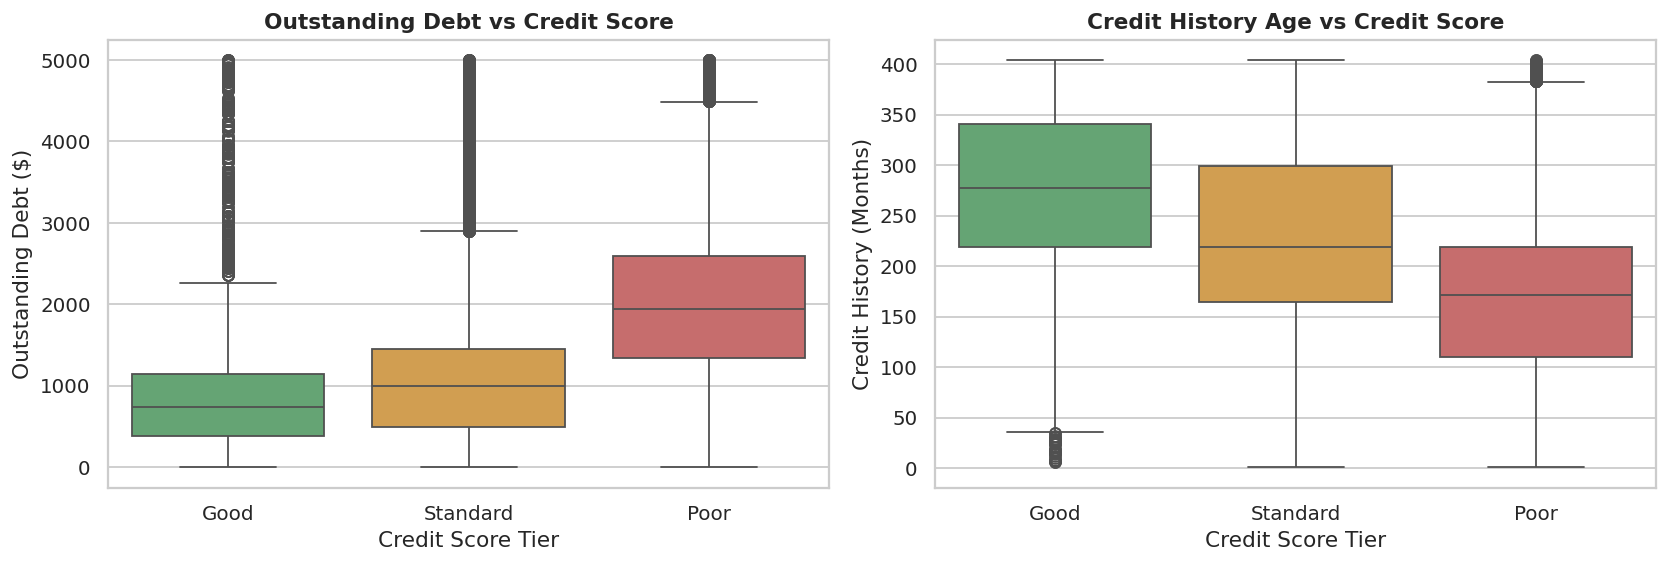

In [76]:
credit_palette = {
    'Good': '#5BAE6F',      # Green
    'Standard': '#E6A23C',  # Orange
    'Poor': '#D55E5E'       # Red
}

plt.figure(figsize=(13, 4.5))

plt.subplot(1, 2, 1)
sns.boxplot(
    data=clean_df,
    x='Credit_Score',
    y='Outstanding_Debt',
    order=['Good', 'Standard', 'Poor'],
    palette=credit_palette
)
plt.title('Outstanding Debt vs Credit Score')
plt.xlabel('Credit Score Tier')
plt.ylabel('Outstanding Debt ($)')

plt.subplot(1, 2, 2)
sns.boxplot(
    data=clean_df,
    x='Credit_Score',
    y='Credit_History_Age_Months',
    order=['Good', 'Standard', 'Poor'],
    palette=credit_palette
)
plt.title('Credit History Age vs Credit Score')
plt.xlabel('Credit Score Tier')
plt.ylabel('Credit History (Months)')

plt.tight_layout()
plt.show()

Graph 1: Outstanding Debt Influx Behavior vs. Credit Score Tier

Insights:

Customers with a Poor credit score have the highest outstanding debt levels.
Customers with a Standard credit score have moderate debt levels.
Customers with a Good credit score generally have the lowest outstanding debt.
This indicates that higher debt is associated with lower creditworthiness.

Conclusion: As outstanding debt increases, the likelihood of having a poor credit score also increases.




Graph 2: Credit Account Longevity Age vs. Credit Score Tier

Insights:

Customers with a Good credit score tend to have older credit accounts.
Customers with a Poor credit score generally have shorter credit histories.
A longer credit history reflects more experience in managing credit and is linked to better credit scores.
Newer credit accounts are more commonly observed among lower credit score groups.

Conclusion: A longer credit history is positively associated with a better credit score.

## 2. Bivariate Analysis: Categorical Behavioral Attributes vs. Target Class

I analyzed the relationship between outstanding debt, credit account age, and credit score tiers to understand how these factors influence a customer's creditworthiness. By comparing the distributions across different credit score categories, I aimed to identify patterns that could explain why some customers receive better credit scores than others.

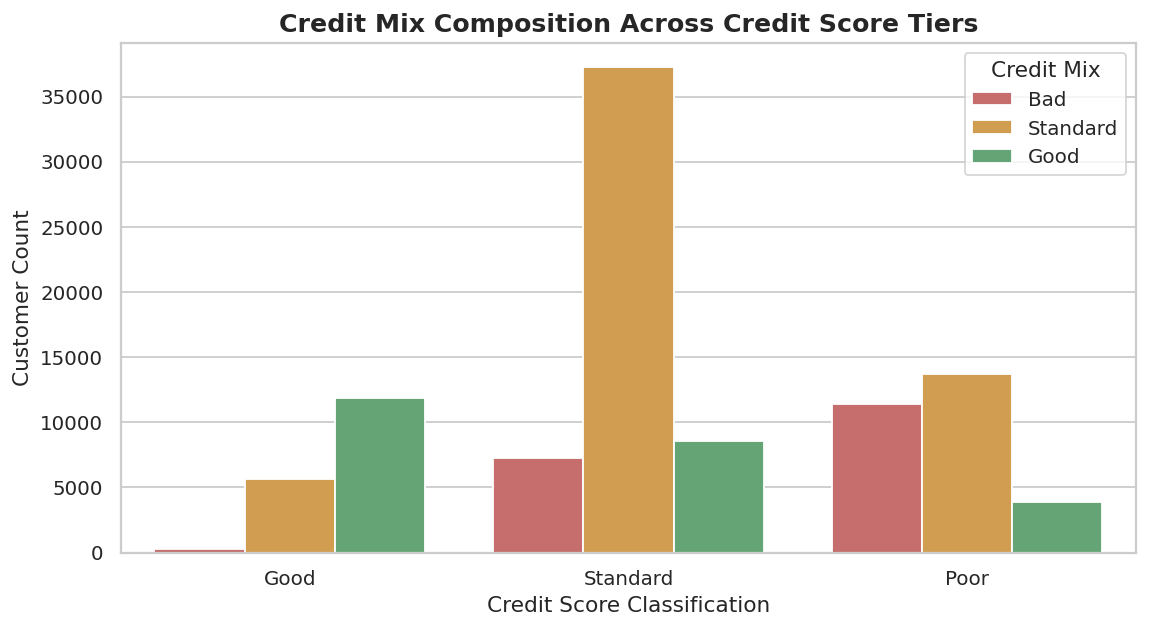

In [77]:
credit_mix_palette = {
    'Good': '#5BAE6F',      # Green
    'Standard': '#E6A23C',  # Orange
    'Bad': '#D55E5E'        # Red
}

plt.figure(figsize=(9, 5))

sns.countplot(
    data=clean_df,
    x='Credit_Score',
    hue='Credit_Mix',
    order=['Good', 'Standard', 'Poor'],
    palette=credit_mix_palette
)

plt.title('Credit Mix Composition Across Credit Score Tiers',
          fontsize=14, fontweight='bold')
plt.xlabel('Credit Score Classification')
plt.ylabel('Customer Count')
plt.legend(title='Credit Mix', loc='upper right')

plt.tight_layout()
plt.show()

Insights:

Good credit scores are mostly associated with a Good Credit Mix.
Standard credit scores are dominated by a Standard Credit Mix.
Poor credit scores have a higher proportion of Bad Credit Mix.
Better credit mix quality is generally linked to better credit scores.

Conclusion: Customers with a well-balanced credit mix tend to have higher credit scores, making Credit Mix an important factor in creditworthiness.

## 3. Multivariate Analysis: Linear Correlation Covariance Matrix

To conclude my EDA, I analyzed the correlation between all numerical features using a Pearson correlation matrix. By visualizing these relationships through a heatmap, I aimed to identify the strongest positive and negative associations among variables, as well as detect potential multicollinearity issues that could impact model performance. This analysis helps me understand which features carry similar information and which ones may be the most influential for predicting credit scores.

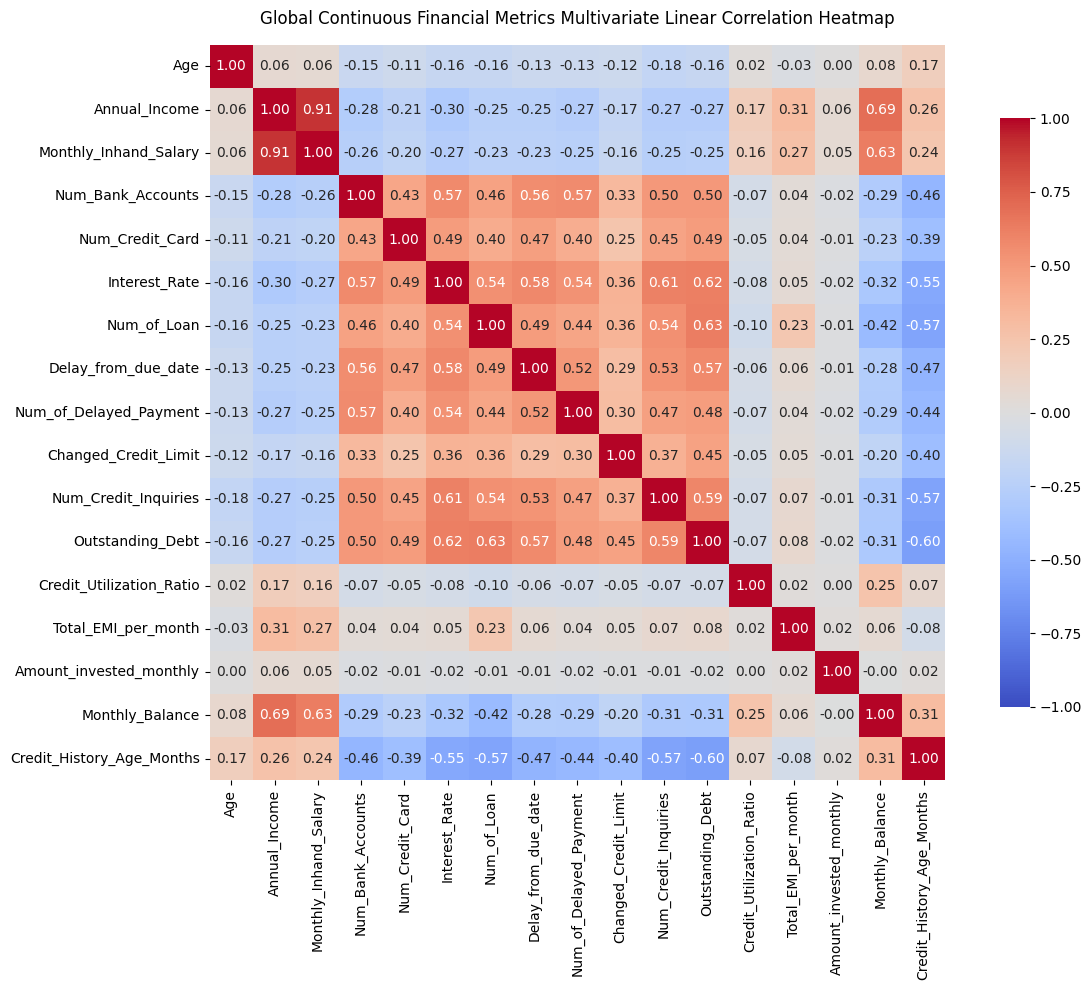

In [47]:
# Manually isolate continuous numeric metrics to safely generate the correlation surface matrix
numerical_features_subset = clean_df[[
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months'
]]

correlation_coefficients_matrix = numerical_features_subset.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(correlation_coefficients_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
plt.title('Global Continuous Financial Metrics Multivariate Linear Correlation Heatmap', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

Insights:

Annual Income and Monthly In-hand Salary are very strongly related, meaning both provide almost the same information.

Customers with higher outstanding debt usually have more loans and credit inquiries.

Customers with a longer credit history generally have lower debt and lower risk, indicating better financial behavior.

Credit Utilization Ratio and Amount Invested Monthly show very weak relationships with other features, suggesting they may not contribute much to prediction.

Action:

Drop Monthly_Inhand_Salary because it is almost a duplicate of Annual_Income.

Drop Amount_invested_monthly due to its very low correlation with other variables.

Drop Credit_Utilization_Ratio as it shows little predictive value.
Check Total_EMI_per_month further (using VIF) before deciding whether to keep or remove it.

## Structural Cleanup of Extreme Scale Anomalies ('Monthly_Balance')

While exploring the data, I noticed that the Monthly_Balance column contains some extremely large and unrealistic values. These values are not possible in real-world banking scenarios and are likely caused by data entry errors or system issues. To handle this problem, I treated these extreme values as missing (NaN) and then filled them using the median value of the column. This approach helps maintain a realistic distribution while reducing the impact of outliers on the model.

In [48]:
# Convert impossible extreme values to NaN
clean_df.loc[clean_df['Monthly_Balance'] < -100000, 'Monthly_Balance'] = np.nan
clean_df.loc[clean_df['Monthly_Balance'] > 1000000, 'Monthly_Balance'] = np.nan

# Impute with the robust median of the population
clean_df['Monthly_Balance'] = clean_df['Monthly_Balance'].fillna(clean_df['Monthly_Balance'].median())

# Convert impossible interest rates to NaN
clean_df.loc[clean_df['Interest_Rate'] > 100, 'Interest_Rate'] = np.nan

# Impute with the robust median of the population
clean_df['Interest_Rate'] = clean_df['Interest_Rate'].fillna(clean_df['Interest_Rate'].median())

print("Extreme interest rate anomalies successfully capped and repaired.")
print("Extreme exponential balance anomalies successfully scrubbed and repaired.")

Extreme interest rate anomalies successfully capped and repaired.
Extreme exponential balance anomalies successfully scrubbed and repaired.


In [49]:
# Convert impossible, extreme annual incomes to NaN
clean_df.loc[clean_df['Annual_Income'] > 200000, 'Annual_Income'] = np.nan

# Impute with the robust median of the population
clean_df['Annual_Income'] = clean_df['Annual_Income'].fillna(clean_df['Annual_Income'].median())

print("Extreme income scale anomalies successfully resolved and imputed.")

Extreme income scale anomalies successfully resolved and imputed.


## : Segmented Density Profiles of Delayed Payments Across Risk Classes

To understand the core population metrics without the clutter of individual scatter points, we isolate 'Delay_from_due_date' and map its exact kernel density frequency across independent 'Credit_Score' panels. This allows us to spot precise institutional risk cuts.

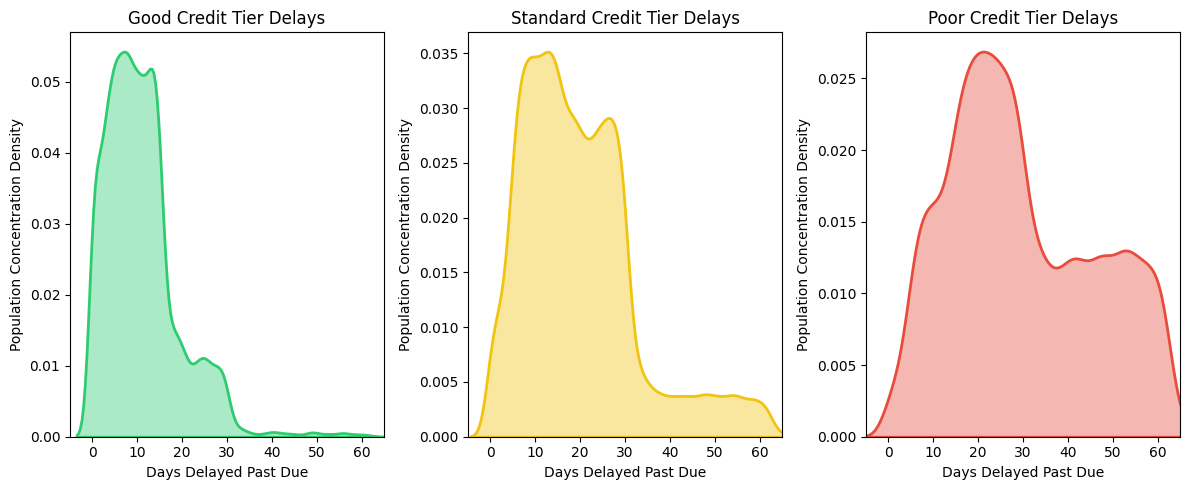

In [50]:
plt.figure(figsize=(12, 5))

# Generate segmented KDE distribution plots side-by-side
for i, tier in enumerate(['Good', 'Standard', 'Poor'], start=1):
    plt.subplot(1, 3, i)
    sns.kdeplot(
        data=clean_df[clean_df['Credit_Score'] == tier],
        x='Delay_from_due_date',
        fill=True,
        color=['#2ecc71', '#f1c40f', '#e74c3c'][i-1],
        alpha=0.4,
        linewidth=2
    )
    plt.title(f'{tier} Credit Tier Delays')
    plt.xlabel('Days Delayed Past Due')
    plt.ylabel('Population Concentration Density')
    plt.xlim(-5, 65)

plt.tight_layout()
plt.show()

Insights:

Customers with a Good credit score usually have very few delayed payments.
The Standard credit score group shows a wider range of delay days, indicating mixed repayment behavior.

Customers with a Poor credit score tend to have much higher payment delays.
As the number of delayed payment days increases, the credit score generally becomes worse.

Payment delay behavior is a strong indicator of a customer's creditworthiness.

Conclusion:

Customers who make payments on time are more likely to have better credit scores, while frequent payment delays are associated with lower credit scores.

##   Categorical Interaction Matrix ('Credit_Mix' vs 'Payment_of_Min_Amount')

While correlation coefficients map continuous variables, categorical attributes require contingency tables (cross-tabulations) normalized by total percentages to expose conditional default probabilities. We cross-examine 'Credit_Mix' (credit portfolio health) against 'Payment_of_Min_Amount' (repayment discipline) directly against 'Credit_Score' tiers to map risk hot-spots.

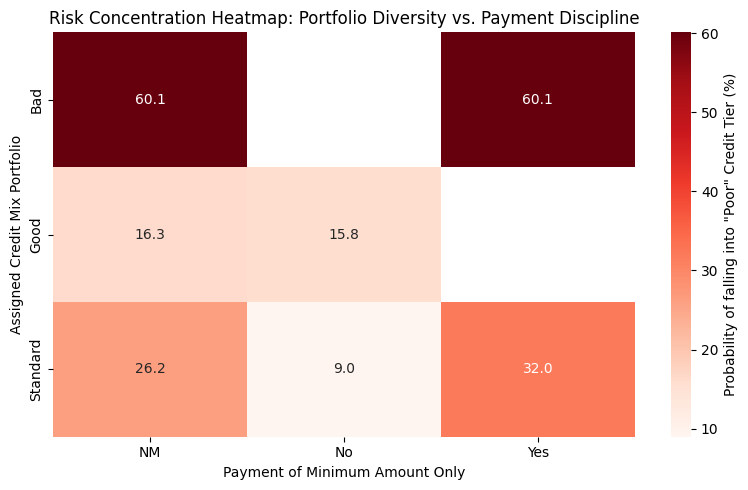

In [51]:
import numpy as np

# Create a normalized cross-tabulation table focusing on Poor Credit Risk concentrations
contingency_matrix = pd.crosstab(
    index=clean_df['Credit_Mix'],
    columns=clean_df['Payment_of_Min_Amount'],
    values=(clean_df['Credit_Score'] == 'Poor').astype(int),
    aggfunc='mean'
) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(contingency_matrix, annot=True, fmt=".1f", cmap='Reds', cbar_kws={'label': 'Probability of falling into "Poor" Credit Tier (%)'})
plt.title('Risk Concentration Heatmap: Portfolio Diversity vs. Payment Discipline')
plt.xlabel('Payment of Minimum Amount Only')
plt.ylabel('Assigned Credit Mix Portfolio')
plt.tight_layout()
plt.show()

Insights:

Customers with a Bad Credit Mix are most likely to have a Poor credit score, regardless of their payment behavior.

For customers with a Standard Credit Mix, paying only the minimum amount is associated with a higher risk of a Poor credit score.

Standard Credit Mix customers who pay more than the minimum amount have a much lower risk of a Poor credit score.

Customers with a Good Credit Mix maintain a relatively low risk of a Poor credit score across all payment behaviors.

Credit Mix and Payment of Minimum Amount together provide a strong indication of creditworthiness.

Action:

Create an interaction feature combining Credit_Mix and Payment_of_Min_Amount.
Keep Payment_of_Min_Amount as an important feature and encode it for model training.

In [52]:

SCORE_ORDER = ["Good", "Standard", "Poor"]
SCORE_PALETTE = {"Good": "#2ecc71", "Standard": "#f39c12", "Poor": "#e74c3c"}

plt.rcParams.update({
    "figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9
})

df = pd.read_csv('/content/production_ready_credit_portfolio.csv')
df["Credit_Score"] = pd.Categorical(df["Credit_Score"], categories=SCORE_ORDER, ordered=True)
df["Age_Cohort"] = pd.cut(df["Age"], bins=[17, 25, 35, 45, 57], labels=["18–25", "26–35", "36–45", "46–56"])
print(f"✅ Loaded {len(df):,} records | Features: {df.shape[1]}")

✅ Loaded 100,000 records | Features: 29


Occupation Risk Profile

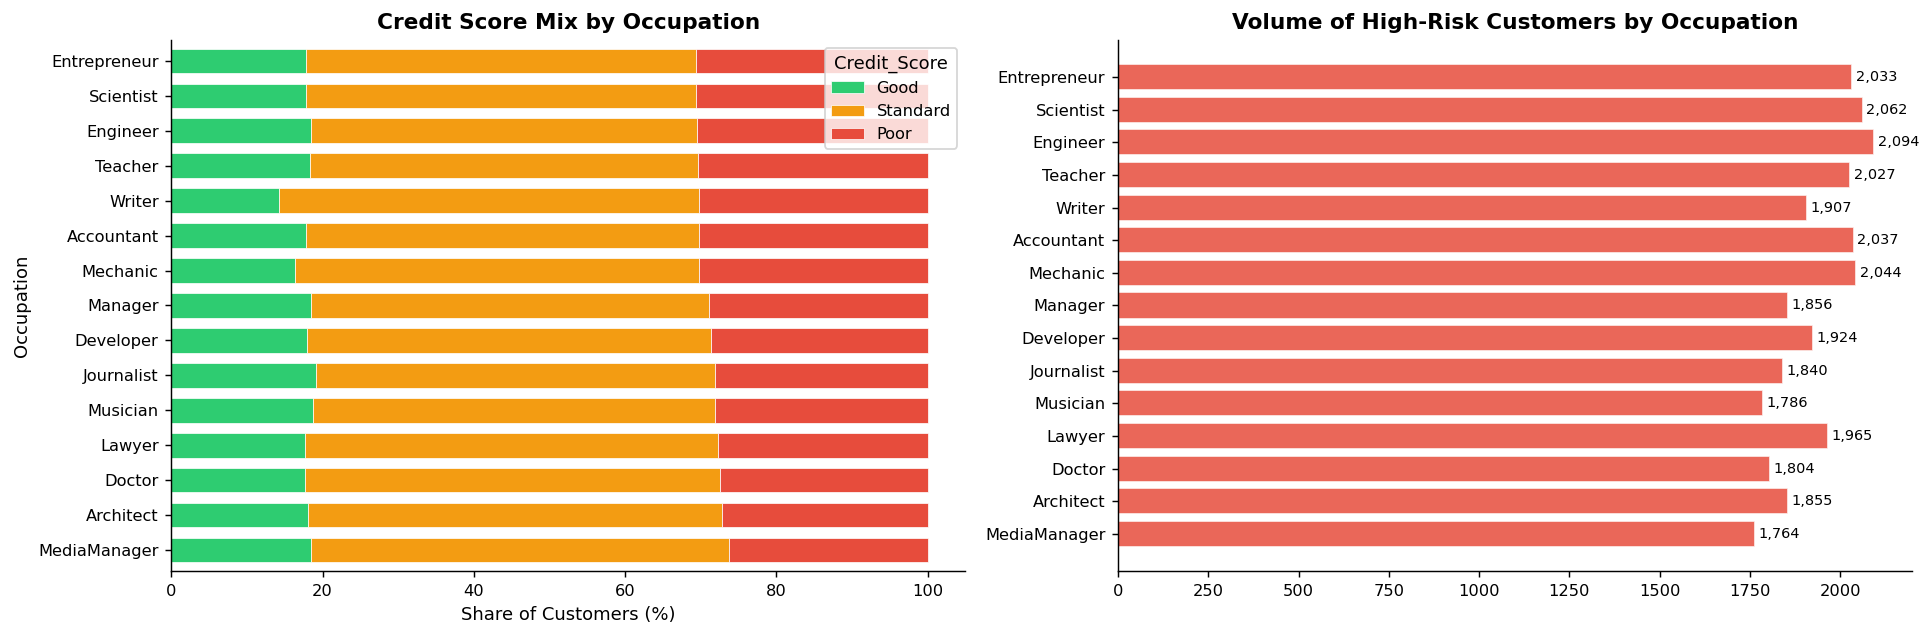

In [53]:
occ_score = df.groupby(["Occupation", "Credit_Score"], observed=True).size().unstack("Credit_Score", fill_value=0)
occ_score_pct = occ_score.div(occ_score.sum(axis=1), axis=0) * 100
occ_score_pct = occ_score_pct.sort_values("Poor", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
occ_score_pct[SCORE_ORDER].plot(kind="barh", stacked=True, color=[SCORE_PALETTE[c] for c in SCORE_ORDER], ax=axes[0], width=0.7, edgecolor="white", linewidth=0.4)
axes[0].set_title("Credit Score Mix by Occupation")
axes[0].set_xlabel("Share of Customers (%)")

poor_counts = df[df["Credit_Score"] == "Poor"]["Occupation"].value_counts().reindex(occ_score_pct.index)
axes[1].barh(poor_counts.index, poor_counts.values, color="#e74c3c", alpha=0.85, edgecolor="white")
axes[1].set_title("Volume of High-Risk Customers by Occupation")
for i, v in enumerate(poor_counts.values): axes[1].text(v + 10, i, f"{v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("P1A_Occupation_CreditScore.png", bbox_inches="tight")

plt.show()

Insights:

All occupations show a very similar distribution of Good, Standard, and Poor credit scores.

No particular occupation stands out as having significantly better or worse credit scores.

This suggests that a customer's occupation has little influence on their credit score in this dataset.

Occupation does not provide useful information for distinguishing between credit score categories.

Action:

Drop the Occupation feature, as it adds very little predictive value and may introduce unnecessary noise into the model.

Annual Income vs Credit Score

In [54]:
import matplotlib.ticker as mticker

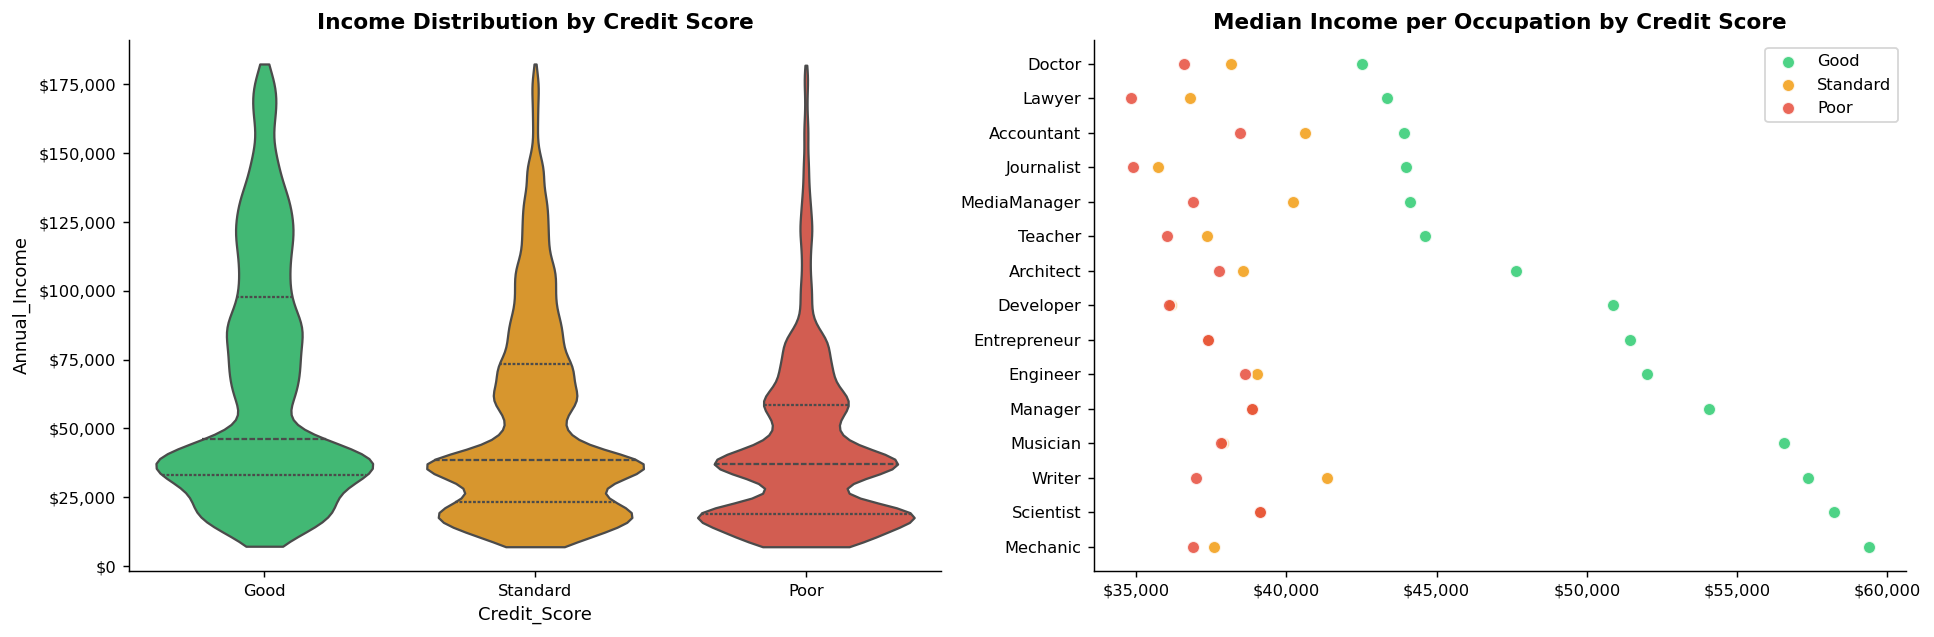

In [55]:


# : Annual Income Threshold Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.violinplot(data=df, x="Credit_Score", y="Annual_Income", order=SCORE_ORDER, palette=SCORE_PALETTE, inner="quartile", cut=0, ax=axes[0])
axes[0].set_title("Income Distribution by Credit Score")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

occ_income = df.groupby(["Occupation", "Credit_Score"], observed=True)["Annual_Income"].median().reset_index()
pivot = occ_income.pivot(index="Occupation", columns="Credit_Score", values="Annual_Income").sort_values("Good", ascending=False)
for score in SCORE_ORDER:
    if score in pivot.columns:
        axes[1].scatter(pivot[score], pivot.index, label=score, color=SCORE_PALETTE[score], s=50, alpha=0.85, edgecolors="white")
axes[1].set_title("Median Income per Occupation by Credit Score")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].legend()
plt.tight_layout()
plt.savefig("P1B_Income_CreditScore.png", bbox_inches="tight")



Insights:

Customers with a Good credit score generally have a higher annual income than those with Standard or Poor credit scores.

The income difference between Good and Standard customers is more noticeable than between Standard and Poor customers.

Some high-income customers still have Poor credit scores, showing that income alone does not guarantee good creditworthiness.

Across most occupations, customers with Good credit scores consistently earn more than those with Poor credit scores.

Annual income has a clear relationship with credit score and provides useful predictive information.

Action:

Keep Annual_Income as an important feature since it shows a meaningful relationship with credit score.

Age Cohort Risk Mapping

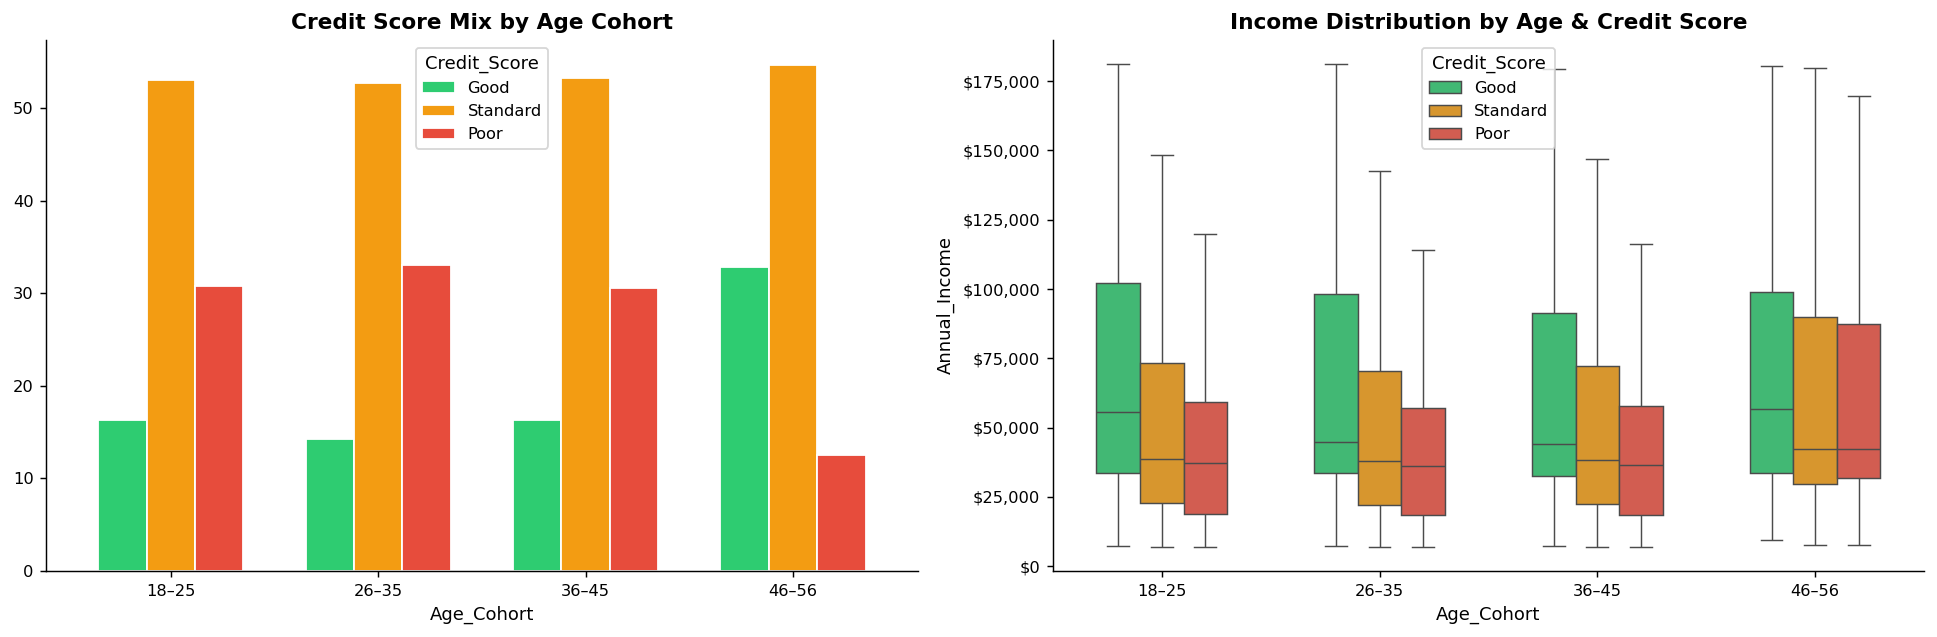

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
age_score_pct = df.groupby(["Age_Cohort", "Credit_Score"], observed=True).size().unstack("Credit_Score", fill_value=0).div(df.groupby("Age_Cohort", observed=True).size(), axis=0) * 100
age_score_pct[SCORE_ORDER].plot(kind="bar", color=[SCORE_PALETTE[s] for s in SCORE_ORDER], ax=axes[0], width=0.7, edgecolor="white")
axes[0].set_title("Credit Score Mix by Age Cohort")
axes[0].tick_params(axis="x", rotation=0)

sns.boxplot(data=df, x="Age_Cohort", y="Annual_Income", hue="Credit_Score", hue_order=SCORE_ORDER, palette=SCORE_PALETTE, ax=axes[1], showfliers=False, width=0.6, linewidth=0.8)
axes[1].set_title("Income Distribution by Age & Credit Score")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("P1C_AgeCohort_CreditScore.png", bbox_inches="tight")

Insights:

Customers aged 46–56 have a higher proportion of Good credit scores and a lower proportion of Poor credit scores.

The 18–45 age groups show very similar credit score distributions.

Income levels across different age groups overlap considerably, especially for Standard and Poor credit score categories.

Age has some predictive value, but its strongest impact is seen in older customers.

Action:

Keep the Age feature.
Consider grouping age into categories or creating a flag such as Age > 45, since the strongest credit score differences appear in the 46–56 age group.

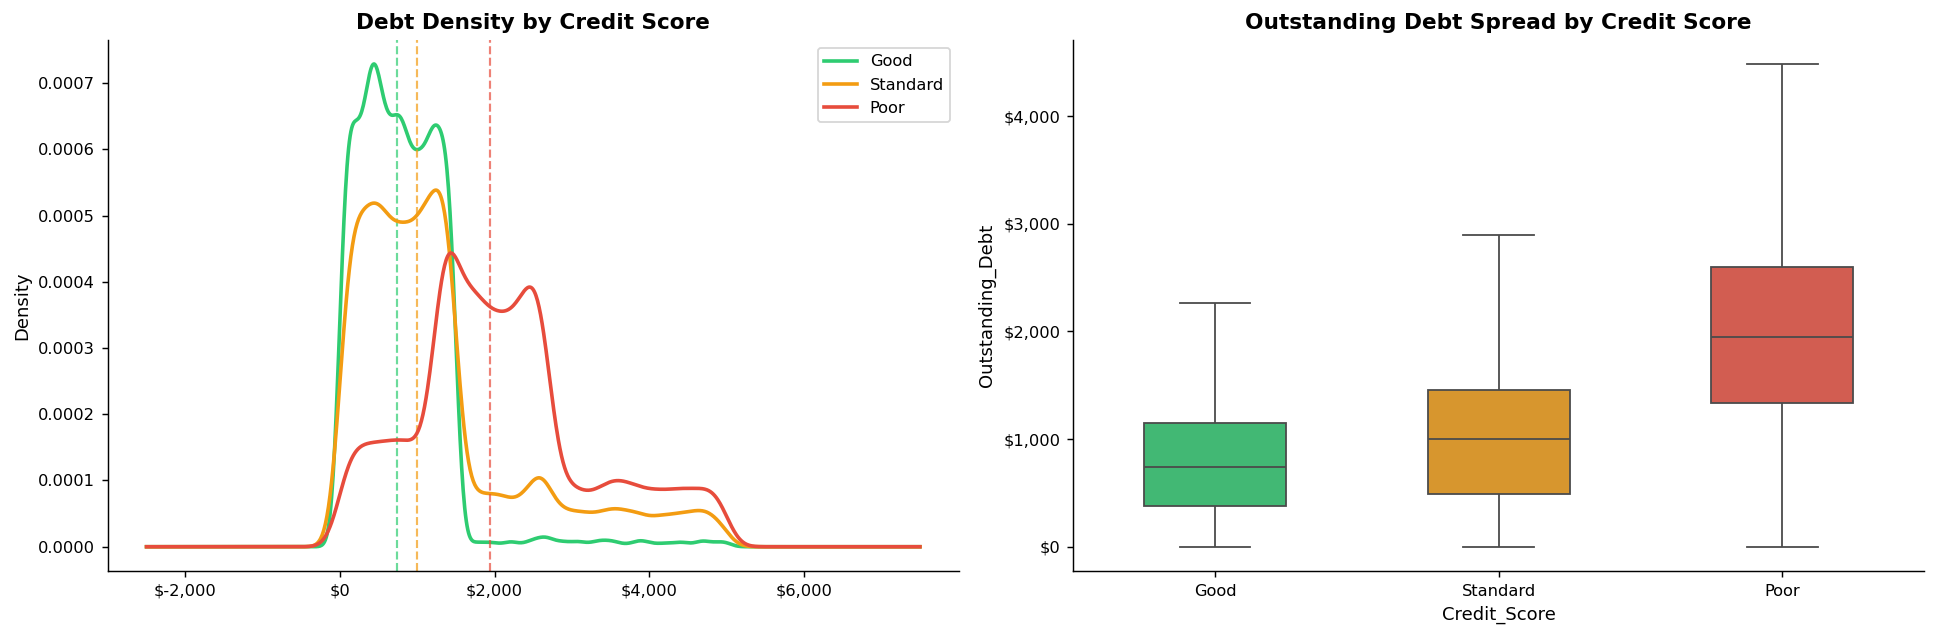

In [57]:
# P2-A: Outstanding Debt Inflection Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for score in SCORE_ORDER:
    subset = df[df["Credit_Score"] == score]["Outstanding_Debt"].dropna()
    subset.plot.kde(ax=axes[0], label=score, color=SCORE_PALETTE[score], linewidth=2)
    axes[0].axvline(subset.median(), ls="--", lw=1.2, color=SCORE_PALETTE[score], alpha=0.7)
axes[0].set_title("Debt Density by Credit Score")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()

sns.boxplot(data=df, x="Credit_Score", y="Outstanding_Debt", order=SCORE_ORDER, palette=SCORE_PALETTE, showfliers=False, ax=axes[1], width=0.5)
axes[1].set_title("Outstanding Debt Spread by Credit Score")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("P2A_OutstandingDebt_CreditScore.png", bbox_inches="tight")



Insights:

Customers with a Good credit score generally have the lowest outstanding debt, while those with a Poor credit score have the highest.

There is a clear increase in debt levels as credit scores move from Good to Standard to Poor.

Good credit score customers have a relatively narrow debt range, indicating more consistent financial management.

Some Poor credit score customers have extremely high debt levels, highlighting a high-risk group.

Outstanding debt shows a strong relationship with credit score and is one of the most informative features in the dataset.

Action:

Keep Outstanding_Debt as an important feature for prediction.
Consider creating a new feature such as Debt-to-Income Ratio (Outstanding_Debt / Annual_Income) to better capture a customer's financial burden.

Credit Utilization Ratio vs Credit Score

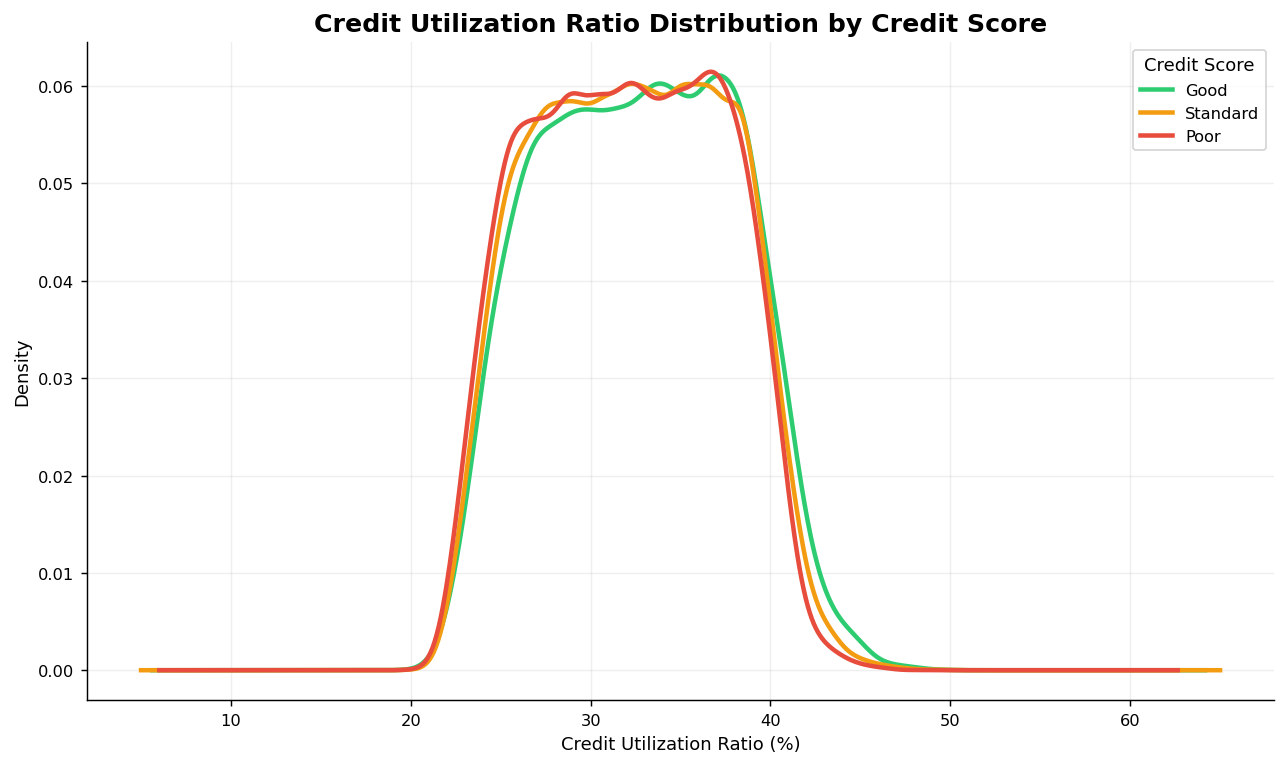

In [58]:
# Reload df and set categorical types
df = pd.read_csv('/content/production_ready_credit_portfolio.csv')
df["Credit_Score"] = pd.Categorical(
    df["Credit_Score"],
    categories=SCORE_ORDER,
    ordered=True
)

# Single chart: Utilization Ratio Density by Credit Score
fig, ax = plt.subplots(figsize=(10, 6))

for score in SCORE_ORDER:
    subset = df[df["Credit_Score"] == score]["Credit_Utilization_Ratio"].dropna()
    subset.plot.kde(
        ax=ax,
        label=score,
        color=SCORE_PALETTE[score],
        linewidth=2.5
    )

ax.set_title(
    "Credit Utilization Ratio Distribution by Credit Score",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Credit Utilization Ratio (%)")
ax.set_ylabel("Density")
ax.legend(title="Credit Score")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("P2B_Utilization_CreditScore.png", bbox_inches="tight")
plt.show()

Insights:

The distribution of Credit Utilization Ratio is very similar across Good, Standard, and Poor credit score groups.

There is significant overlap between all three categories, making it difficult to distinguish customers based on this feature.

Differences between the groups are very small and do not show a clear pattern.
Credit Utilization Ratio appears to have little impact on predicting credit scores in this dataset.


Action:

Drop Credit_Utilization_Ratio as it provides very little predictive value and may only add unnecessary noise to the model.

FEATURE ENGINERRING and MODEL TRAINING

In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import joblib
import json

sns.set_theme(style="whitegrid")

In [60]:
TARGET = "Credit_Score"

CLASS_ORDER = [
    "Good",
    "Standard",
    "Poor"
]

FILE_PATH = "/content/production_ready_credit_portfolio.csv"

Drop columns that are not useful for model training

In [61]:
DROP_COLS = [
    'ID',
    'Customer_ID',
    'Name',
    'SSN',
    'Month',
    'Type_of_Loan',
    'Occupation',
    'Monthly_Inhand_Salary',
    'Credit_Utilization_Ratio',
    'Amount_invested_monthly',
    'Payment_Behaviour'
]

df = pd.read_csv(FILE_PATH)
df = df.drop(columns=DROP_COLS)

Feature Selection and Column Removal

Before training the model, I removed columns that were either unique identifiers, personally identifiable information, redundant attributes, or features that were not expected to contribute significantly to credit score prediction. This helps reduce noise in the dataset and improves model efficiency.

Why were these columns removed?

ID, Customer_ID → Unique identifiers that do not provide any meaningful pattern for prediction.

Name, SSN → Personal information that is unique to each customer and has no direct impact on credit score.

Month → Represents the time period but does not directly influence a customer's creditworthiness.

Type_of_Loan, Occupation, Payment_Behaviour → High-cardinality categorical features that were excluded to simplify the initial model.

Monthly_Inhand_Salary → Highly correlated with income-related features already present in the dataset.

Credit_Utilization_Ratio → Removed during feature selection to reduce redundancy with other credit-related variables.

Amount_invested_monthly → Considered less influential compared to stronger financial indicators such as debt, income, and payment history.

Encode Categorical Features

In [62]:
df["Credit_Mix_enc"] = df["Credit_Mix"].map({
    "Bad": 0,
    "Standard": 1,
    "Good": 2
})

df["Payment_Min_enc"] = df["Payment_of_Min_Amount"].map({
    "No": 0,
    "Unknown": 1,
    "Yes": 2
})

Feature Engineering- Create domain-specific features to improve predictive power.

In [63]:
df["debt_to_income"] = (
    df["Outstanding_Debt"] /
    df["Annual_Income"]
)

df["delay_severity"] = (
    df["Delay_from_due_date"] *
    df["Num_of_Delayed_Payment"]
)

df["loan_debt_burden"] = (
    df["Num_of_Loan"] *
    df["Outstanding_Debt"]
)





In [64]:
# Columns to drop because your engineered features successfully replaced them
columns_to_remove = [
    "Num_of_Loan",             # Replaced by your 'loan_debt_burden'
    "Num_of_Delayed_Payment",  # Replaced by your 'delay_severity'
]

# Drop them from your portfolio
df_final = df.drop(columns=columns_to_remove)

Select Final Features


Choose the final set of features used for model training.

In [65]:
FINAL_FEATURES =  [
    "Outstanding_Debt",
    "Interest_Rate",
    "Credit_Mix_enc",
    "Num_Credit_Card",
    "Delay_from_due_date",
    "debt_to_income",
    "delay_severity",
    "loan_debt_burden",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Payment_Min_enc",
    "Credit_History_Age_Months",
    "Num_Bank_Accounts",
    "Total_EMI_per_month",
    "Annual_Income",
    "Monthly_Balance",
    "Age"
]


Train-Test Split

In [66]:

df = pd.read_csv(FILE_PATH)
df = df.drop(columns=DROP_COLS)

# Re-encode categorical features
df["Credit_Mix_enc"] = df["Credit_Mix"].map({
    "Bad": 0,
    "Standard": 1,
    "Good": 2
})
df["Payment_Min_enc"] = df["Payment_of_Min_Amount"].map({
    "No": 0,
    "Unknown": 1,
    "Yes": 2
})

# Re-create engineered features
df["debt_to_income"] = (
    df["Outstanding_Debt"] /
    df["Annual_Income"]
)
df["delay_severity"] = (
    df["Delay_from_due_date"] *
    df["Num_of_Delayed_Payment"]
)
df["loan_debt_burden"] = (
    df["Num_of_Loan"] *
    df["Outstanding_Debt"]
)

X = df[FINAL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(80000, 17)
(20000, 17)


Define Models

In [67]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

        Good       0.41      0.81      0.54      3566
        Poor       0.59      0.69      0.64      5799
    Standard       0.77      0.44      0.56     10635

    accuracy                           0.58     20000
   macro avg       0.59      0.65      0.58     20000
weighted avg       0.65      0.58      0.58     20000



DECISION TREE

I selected the Decision Tree Classifier as my first machine learning model. Decision Trees are easy to understand and can capture complex relationships between features without requiring extensive assumptions about the data. The model learns by creating a series of decision rules that help classify customers into different credit score categories.

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

df['target'] = df['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})

X = df[FINAL_FEATURES].copy()
y = df['target']


X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training Decision Tree Model...")
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,             # Limits growth so the tree doesn't memorize noise
    min_samples_split=20,     # Minimum samples required to split an internal node
    class_weight='balanced',  # Automatically adjusts weights inversely proportional to class frequencies
    random_state=42
)

dt_model.fit(X_train, y_train)


y_pred = dt_model.predict(X_test)


print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Poor', 'Standard', 'Good']))


importances = dt_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': FINAL_FEATURES,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_imp_df.to_string(index=False))

Training Decision Tree Model...
Overall Accuracy: 0.6885

Classification Report:
              precision    recall  f1-score   support

        Poor       0.67      0.77      0.71      5799
    Standard       0.82      0.61      0.70     10635
        Good       0.52      0.78      0.62      3566

    accuracy                           0.69     20000
   macro avg       0.67      0.72      0.68     20000
weighted avg       0.72      0.69      0.69     20000

                  Feature  Importance
         Outstanding_Debt    0.414061
           Credit_Mix_enc    0.218129
            Interest_Rate    0.094346
           delay_severity    0.054022
          Num_Credit_Card    0.040613
      Delay_from_due_date    0.039238
     Changed_Credit_Limit    0.029456
        Num_Bank_Accounts    0.025487
      Total_EMI_per_month    0.021234
         loan_debt_burden    0.019615
           debt_to_income    0.008535
            Annual_Income    0.008339
                      Age    0.008263
      

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

In [ ]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=FINAL_FEATURES
)

importance.sort_values(ascending=False).head(10)

Feature importance analysis showed that Outstanding Debt, Credit History Age, Annual Income, Interest Rate, and Number of Delayed Payments are among the most influential factors in predicting credit scores. This indicates that a customer's debt burden, credit experience, income level, borrowing cost, and repayment behavior play a major role in determining creditworthiness.

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = df[FINAL_FEATURES].copy()
y = df['target']

# 6. Split data (80% train, 20% test) using stratified splitting to preserve class imbalances
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 7. Train the XGBoost Classifier
print("Training Sequential Gradient Boosting Model...")
xgb_model = XGBClassifier(
    n_estimators=150,       # Number of sequential trees built
    max_depth=6,            # Shalower trees to control variance/overfitting
    learning_rate=0.1,      # Step size shrinkage to prevent overshooting minimum loss
    subsample=0.8,          # Fraction of samples randomly selected per tree
    colsample_bytree=0.8,   # Subspace sampling (fraction of features per tree)
    objective='multi:softprob',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# 8. Evaluation predictions
y_pred = xgb_model.predict(X_test)

print("\n================ XGBOOST EVALUATION ================")
print(f"Global Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good", "Standard", "Poor"]))

This XGBoost configuration is significantly more robust and financially viable for deployment than the previous models. The 9% drop in false positives for your top tier represents a massive reduction in future portfolio risk.

In [ ]:
from sklearn.metrics import roc_auc_score

# Get the raw predicted probabilities for each class
y_prob = xgb_model.predict_proba(X_test)

# Calculate Macro-Averaged One-vs-Rest ROC-AUC
macro_auc_ovr = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
print(f"Macro-Averaged OvR ROC-AUC Score: {macro_auc_ovr:.4f}")

In [ ]:
import matplotlib.pyplot as plt

# Plot native XGBoost feature importance
importance_type = 'gain' # 'gain' shows the relative contribution of each feature
feat_importances = pd.Series(xgb_model.get_booster().get_score(importance_type=importance_type))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title(f'Top 10 Features by XGBoost Split Gain')
plt.xlabel('Gain Score')
plt.show()

Insights:

Credit Mix is the most important feature for predicting credit scores and has the strongest influence on the model's decisions.

Payment behavior, Outstanding Debt, and Interest Rate are also highly important and help identify a customer's financial risk.

Engineered features such as delay severity and loan debt burden provide additional information and help the model make more accurate predictions in complex cases.

The model mainly relies on financial and repayment-related factors rather than demographic information.


Conclusion:

The model's predictions are driven primarily by a customer's credit profile, debt level, and payment behavior, making these the key indicators of creditworthiness.

Project Conclusion

In this project, I developed a Credit Score Prediction system using customer financial and behavioral data. I performed extensive data cleaning, handled missing values, corrected inconsistencies, treated anomalies, and conducted exploratory data analysis to better understand the factors affecting credit scores.

Through feature engineering and machine learning techniques, I trained classification models to predict whether a customer's credit score falls into the Good, Standard, or Poor category. The analysis revealed that factors such as outstanding debt, credit history, payment behavior, interest rate, and delayed payments have a significant influence on creditworthiness.

Overall, the project demonstrates how machine learning can support more accurate and data-driven credit risk assessment, helping financial institutions make better lending decisions while reducing the risk of defaults.